In [2]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")
print(datadir)

/home/lena/Promotion/neurolib/neurolib/whole-brain


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import pickle

from neurolib.models.wc import WCModel
from neurolib.control.optimal_control import oc_wc, cost_functions

import nctpy.utils
import nctpy.metrics
import pandas as pd
import seaborn as sns

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1


def ploterrorrange(a, x_axis, linfit, linfitstd):
    xpos = np.linspace(0., x_axis[-1], 100)
    a.fill_between(xpos, linfit[1]-linfitstd[1] + xpos*(linfit[0]-linfitstd[0]), linfit[1] + xpos*linfit[0], color="red", alpha=0.3 )
    a.fill_between(xpos, linfit[1] + xpos*linfit[0], linfit[1]+linfitstd[1] + xpos*(linfit[0]+linfitstd[0]), color="red", alpha=0.3 )
    xneg = np.linspace(x_axis[0], -1e-3, 100, )
    a.fill_between(xneg, linfit[1]-linfitstd[1] + xneg*(linfit[0]+linfitstd[0]), linfit[1] + xneg*linfit[0], color="red", alpha=0.3 )
    a.fill_between(xneg, linfit[1] + xneg*linfit[0], linfit[1]+linfitstd[1] + xneg*(linfit[0]-linfitstd[0]), color="red", alpha=0.3 )

def get_sphere_coords(x,y,z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z/r)
    phi = np.sign(y)*np.arccos(x/np.sqrt(x**2 + y**2))
    return r, theta, phi

In [4]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

coord_data = pd.read_csv(os.path.join(os.getcwd(), "data", "structural_data", "Sch100_coords.txt"), sep=None, header=None).to_numpy()

/tmp/ipykernel_2759376/854259224.py:16: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  coord_data = pd.read_csv(os.path.join(os.getcwd(), "data", "structural_data", "Sch100_coords.txt"), sep=None, header=None).to_numpy()


In [11]:
with open(os.path.join(datadir, 'wb_L1.pickle'), 'rb') as f:
    data_read = pickle.load(f)

[data_0, data_1, data_2] = data_read

dt = 0.1

rng = np.random.default_rng()
method = scipy.stats.PermutationMethod(n_resamples=2. * 1e3, random_state=rng)
cmap = "cividis"

In [12]:
sys = "discrete"

c_norm = nctpy.utils.matrix_normalization((cmat_av), system=sys)
av_c = nctpy.metrics.ave_control(c_norm, sys)
mod_c = nctpy.metrics.modal_control(c_norm)
wnd = np.sum(cmat_av, axis=0)
nfl = np.sum(dmat_av, axis=0)

nfl -= np.amin(nfl)
nfl /= 1e3

wnfl = np.zeros((N))
for n in range(N):
    wnfl[n] = sum(cmat_av[n,:]*dmat_av[n,:])

r, theta, phi = get_sphere_coords(coord_data[:,0], coord_data[:,1], coord_data[:,2])

[[36, 69, 70, 88], [21, 36, 49, 65, 68, 75, 88], [0, 9, 10, 11, 15, 21, 24, 25, 32, 36, 38, 65, 68, 88]]
4 7 14


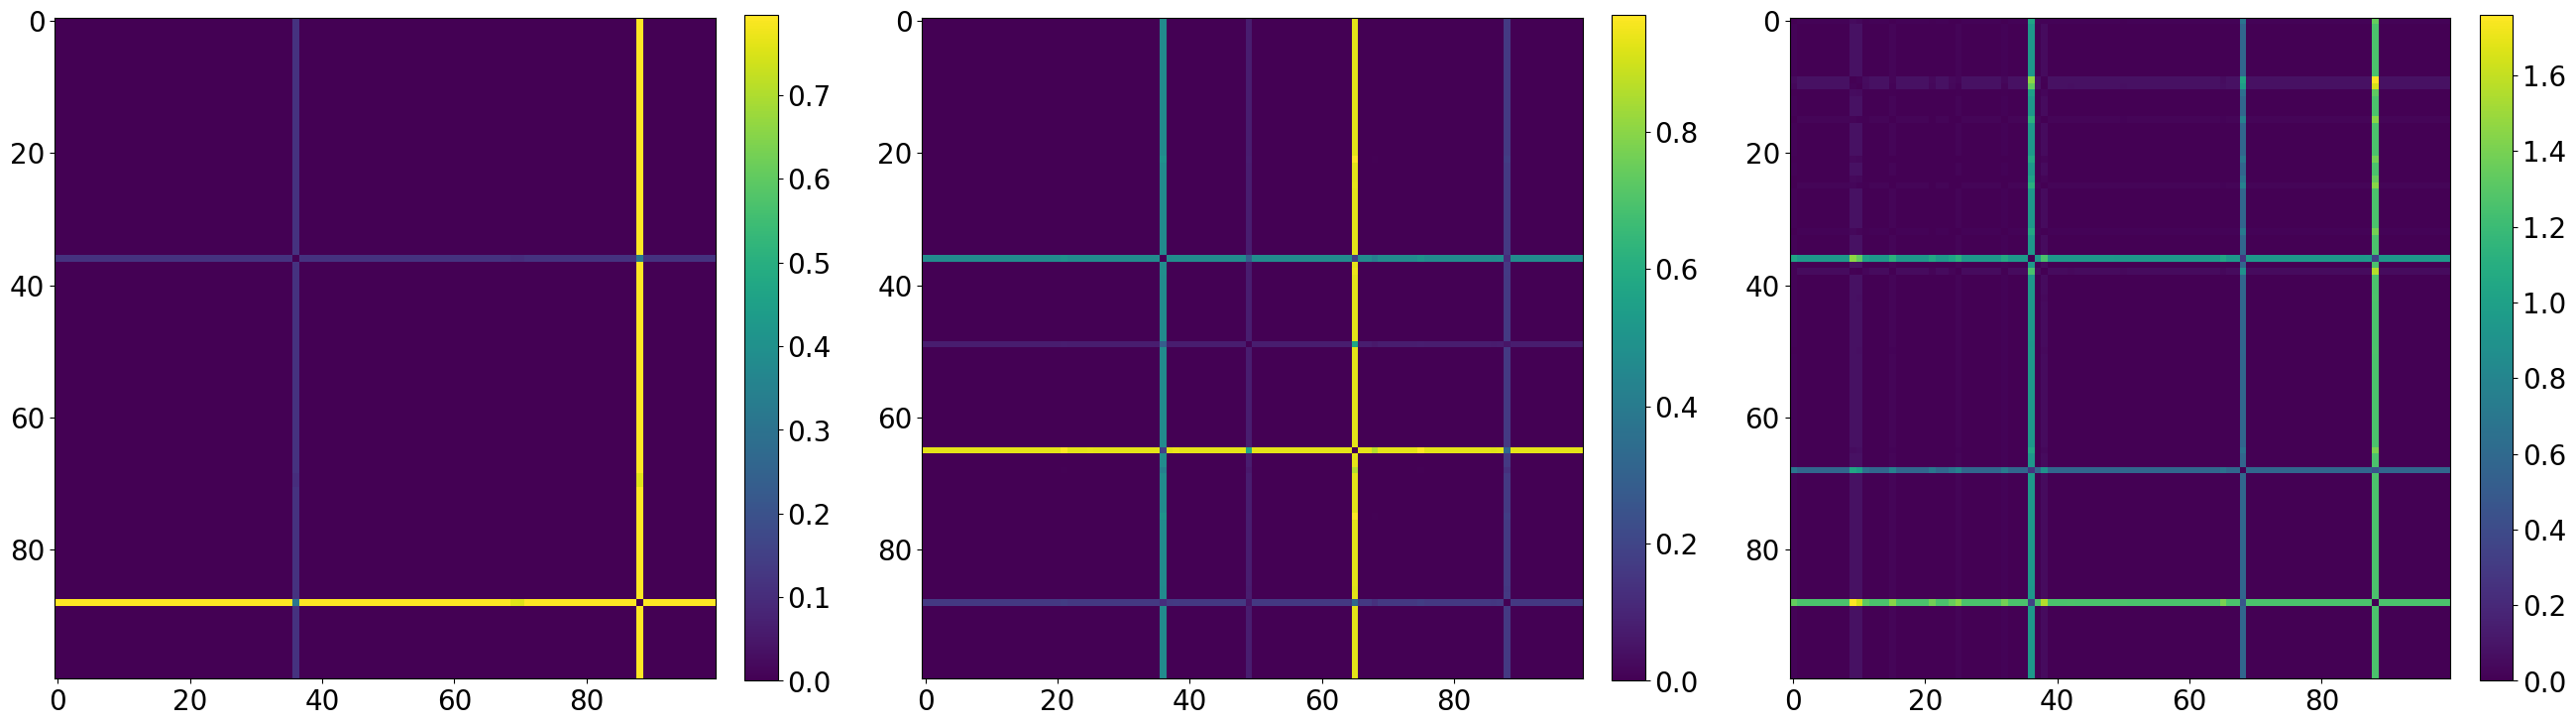

In [17]:
peak_times0 = np.zeros((N))
for n in range(N):
    peak_times0[n] = scipy.signal.find_peaks(data_0["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
peak_times0 -= np.amin(peak_times0)
peak_times0 *= dt
peak_time_order0 = np.argsort(peak_times0)

energy_nodewise = np.zeros((3,N))
input_nodewise = np.zeros((3,N))
mdn = [[], [], []]
for wi in range(3):
    for n in range(N):
        energy_nodewise[wi,n] = np.sum(data_0["control"][wi][n,0,:])**2 * dt
        input_nodewise[wi,n] = np.sum(np.abs(data_0["control"][wi][n,0,:])) * dt
        if energy_nodewise[wi,n] > 0.2:
            mdn[wi].append(n)

control_times0 = np.zeros((3,N))
min_c = 1000.
for wi in range(3):
    for n in mdn[wi]:
        if len(scipy.signal.find_peaks(np.abs(data_0["control"][wi][n,0,20:]))[0]) > 0:
            control_times0[wi,n] = scipy.signal.find_peaks(np.abs(data_0["control"][wi][n,0,20:]))[0][0]
            if control_times0[wi,n] < min_c:
                min_c = control_times0[wi,n]
    control_times0[wi,mdn[wi]] -= min_c

distmat = np.zeros((3,N,N))
cnd = np.zeros((3,N))

for wi in range(3):
    for n1 in range(N):
        for n2 in range(n1+1, N):
            distmat[wi,n1,n2] = np.sum( (data_0["control"][wi][n1,0,:] - data_0["control"][wi][n2,0,:])**2 )*dt
            distmat[wi,n2,n1] = distmat[wi,n1,n2].copy()

    cnd[wi,:] = np.sum(distmat[wi,:,:], axis=0)
        
print(mdn)
print(len(mdn[0]), len(mdn[1]), len(mdn[2]))

fig, ax = plt.subplots(1,3, figsize=(32,12))
for wi in range(3):
    heatmap = ax[wi].imshow(distmat[wi,:,:])
    bar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)
plt.show()

/tmp/ipykernel_2686281/3568892516.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colmap = mpl.cm.get_cmap('YlOrRd')


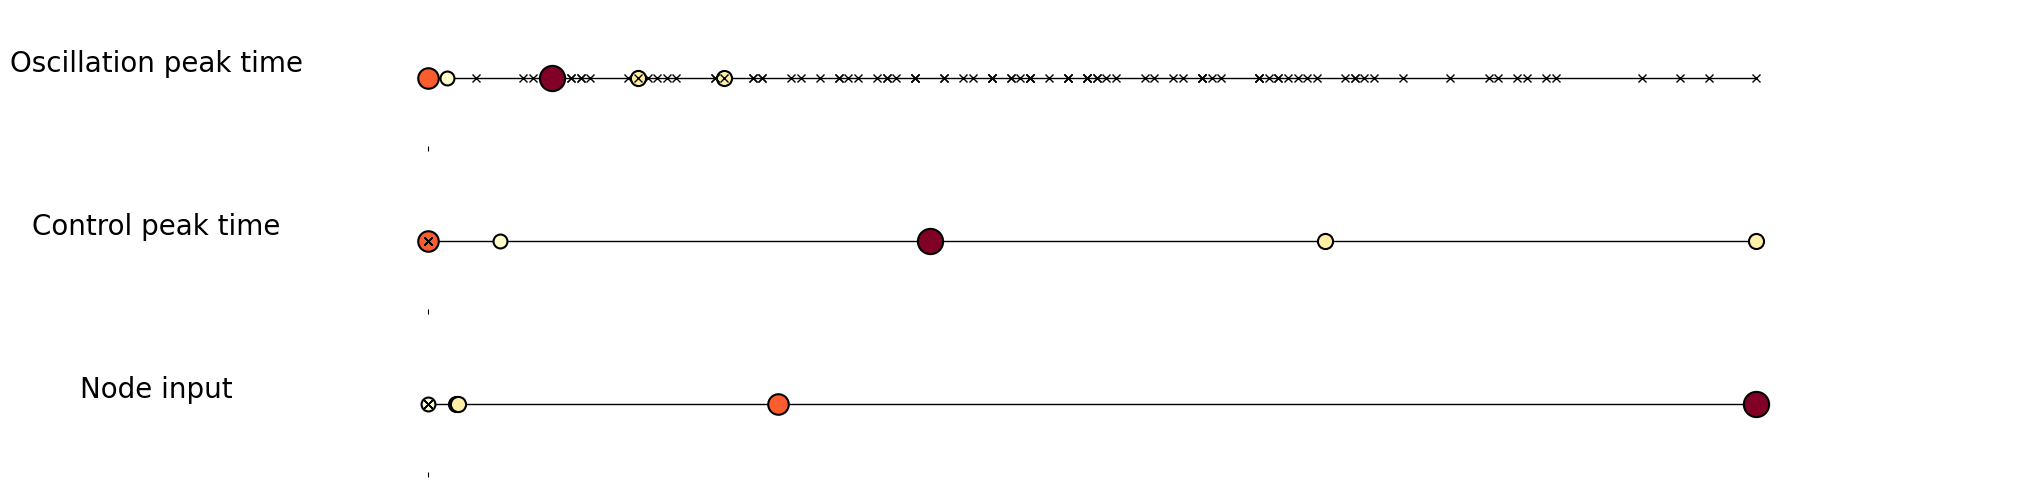

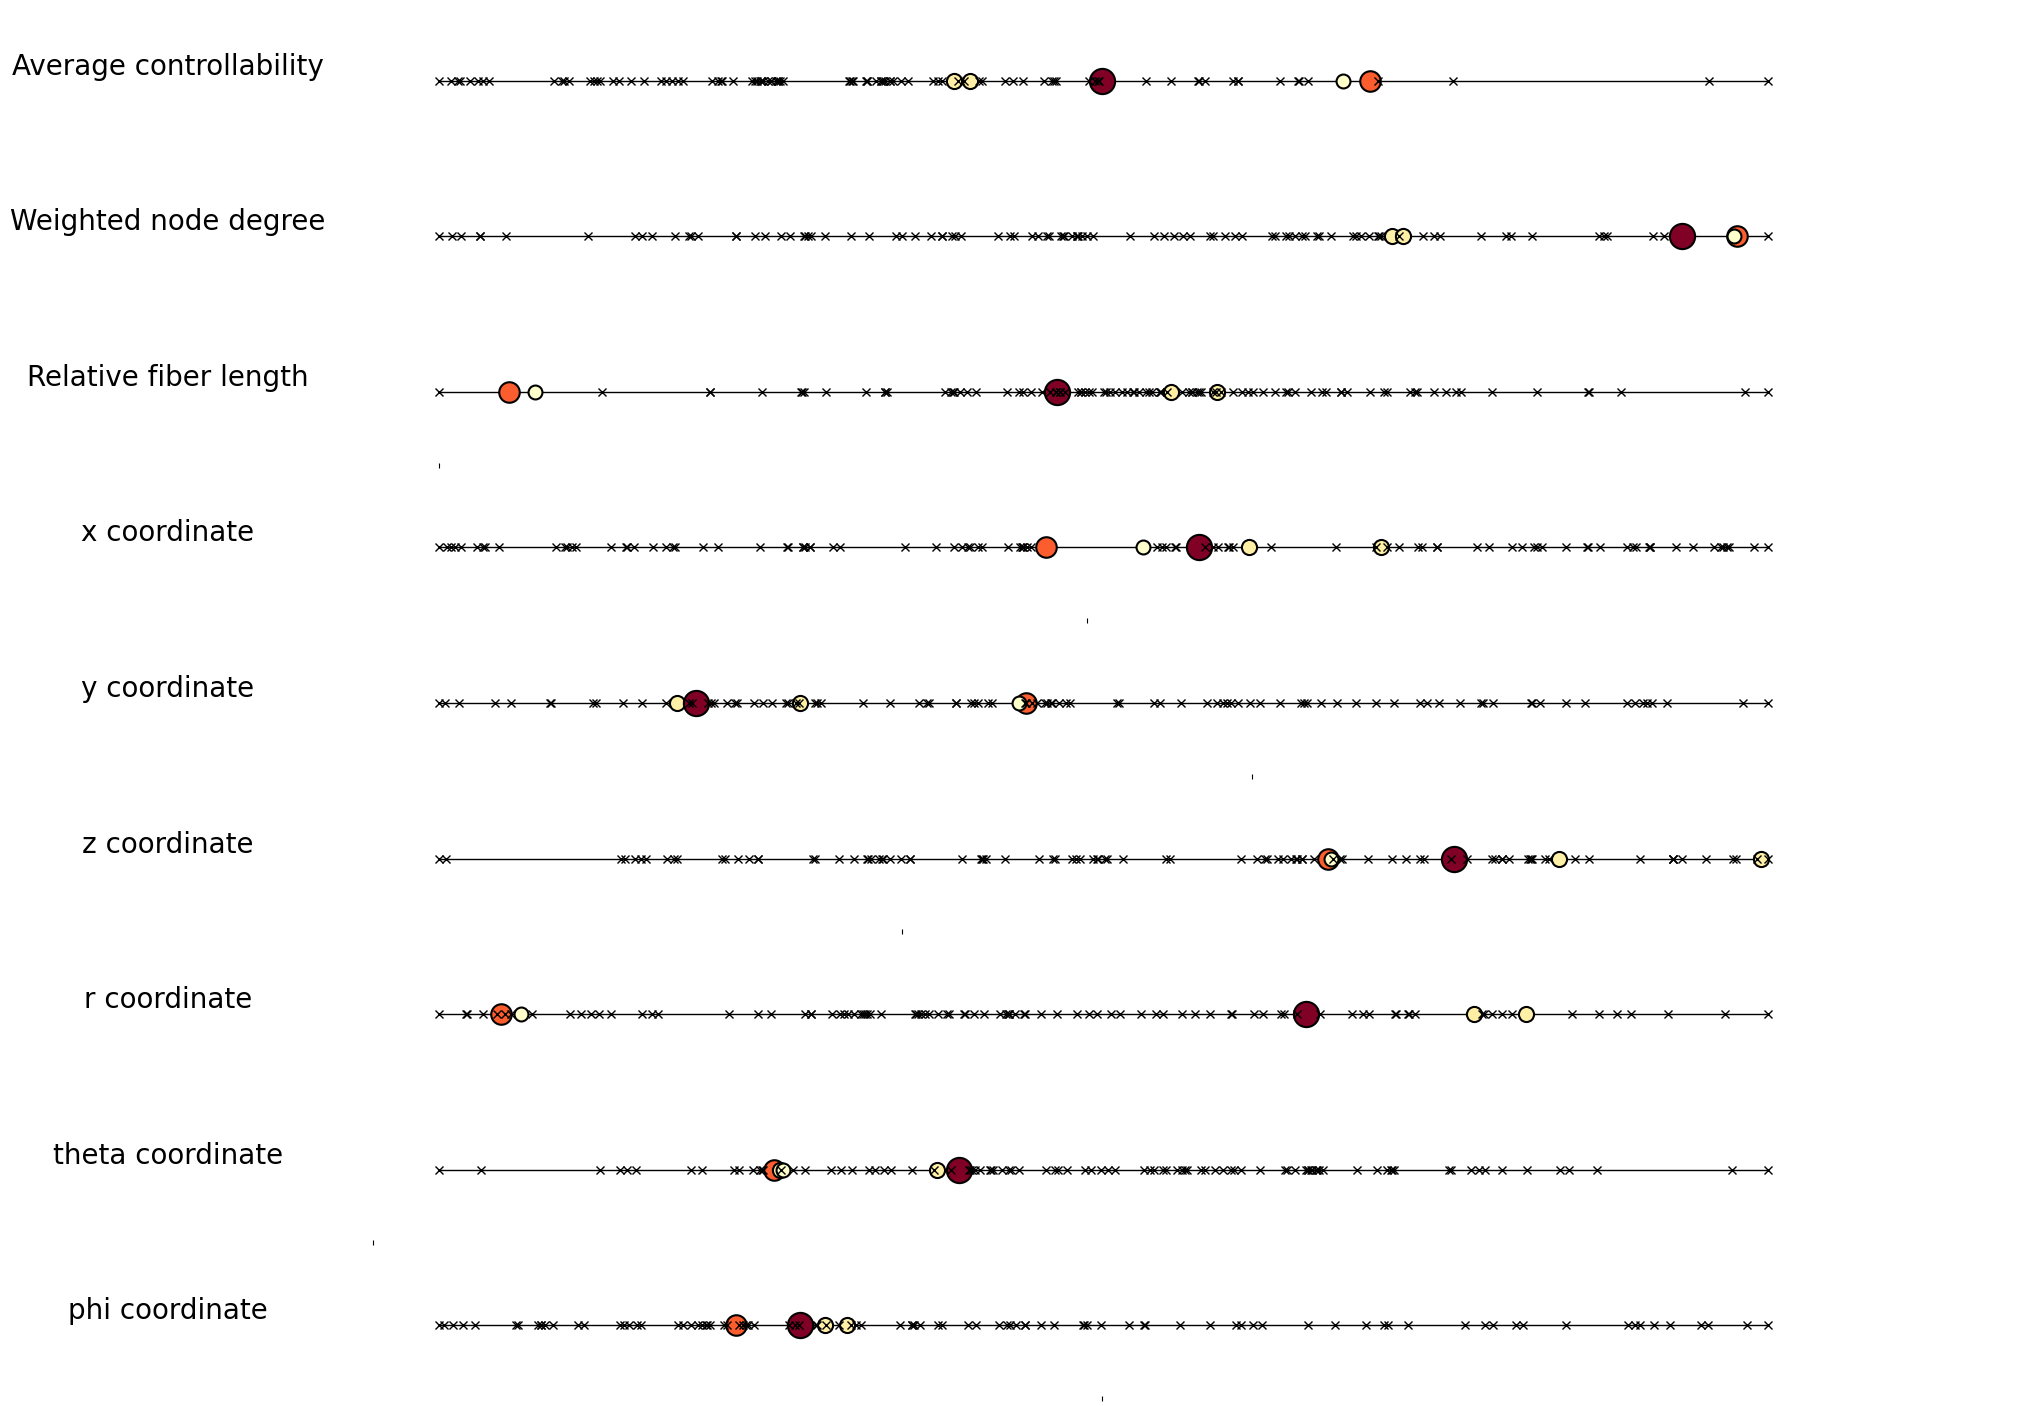

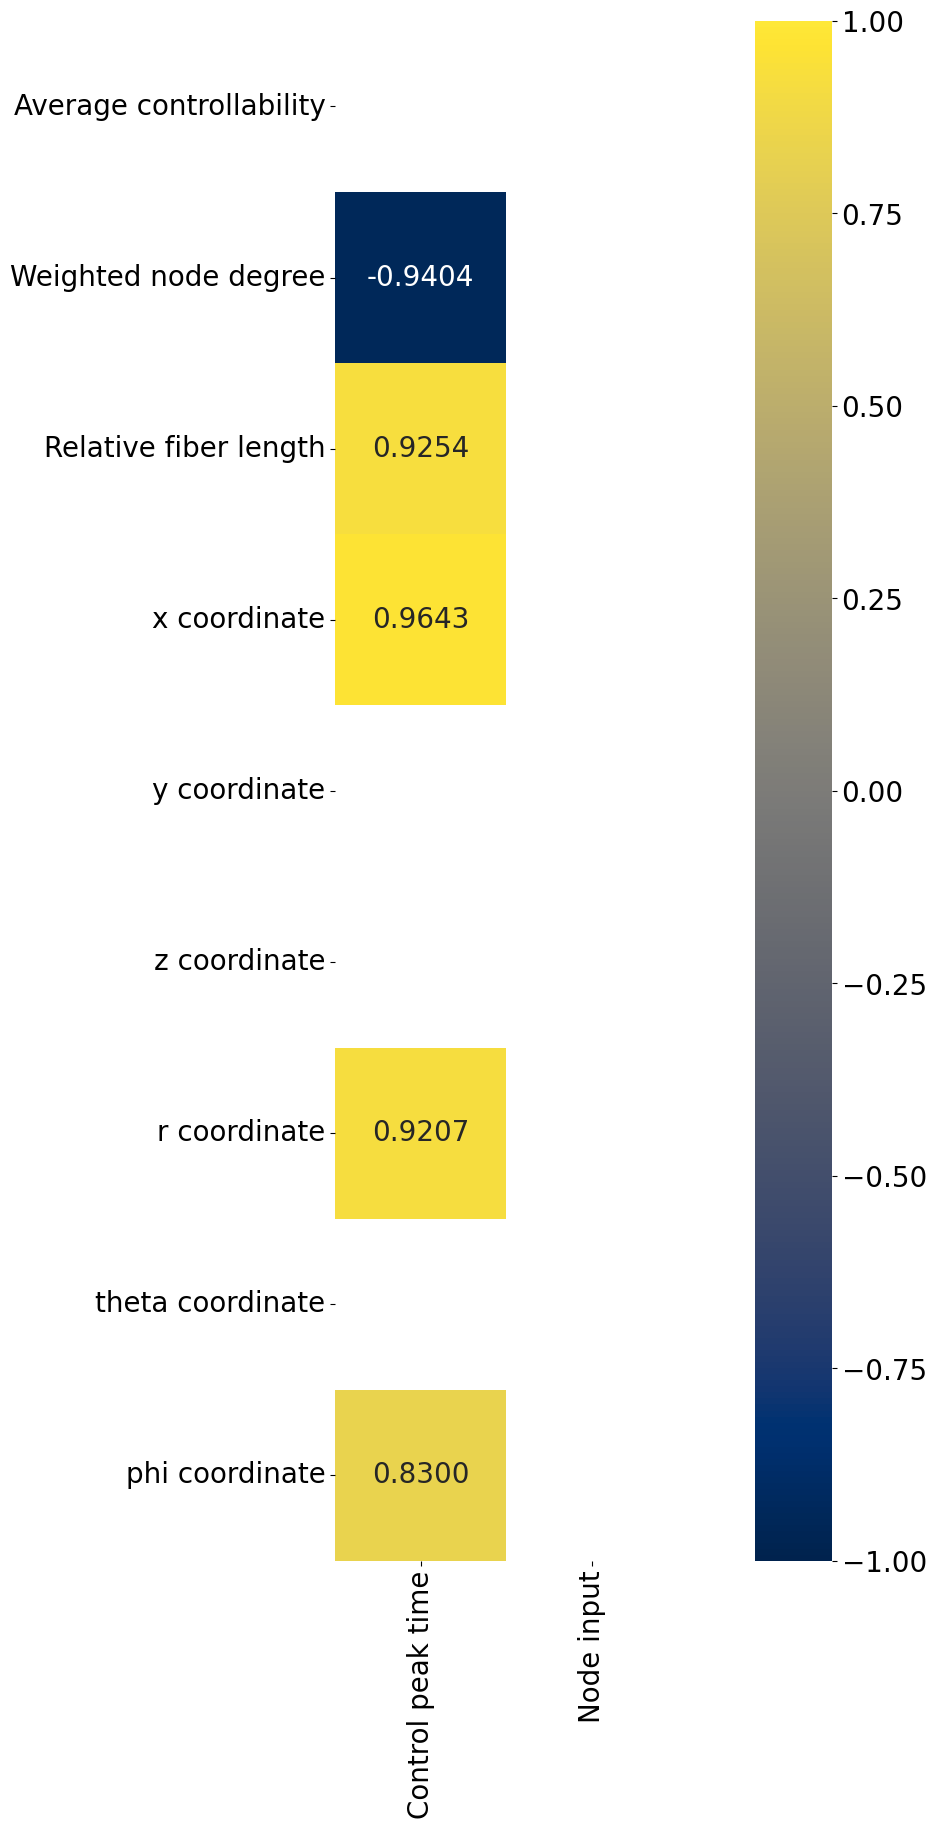

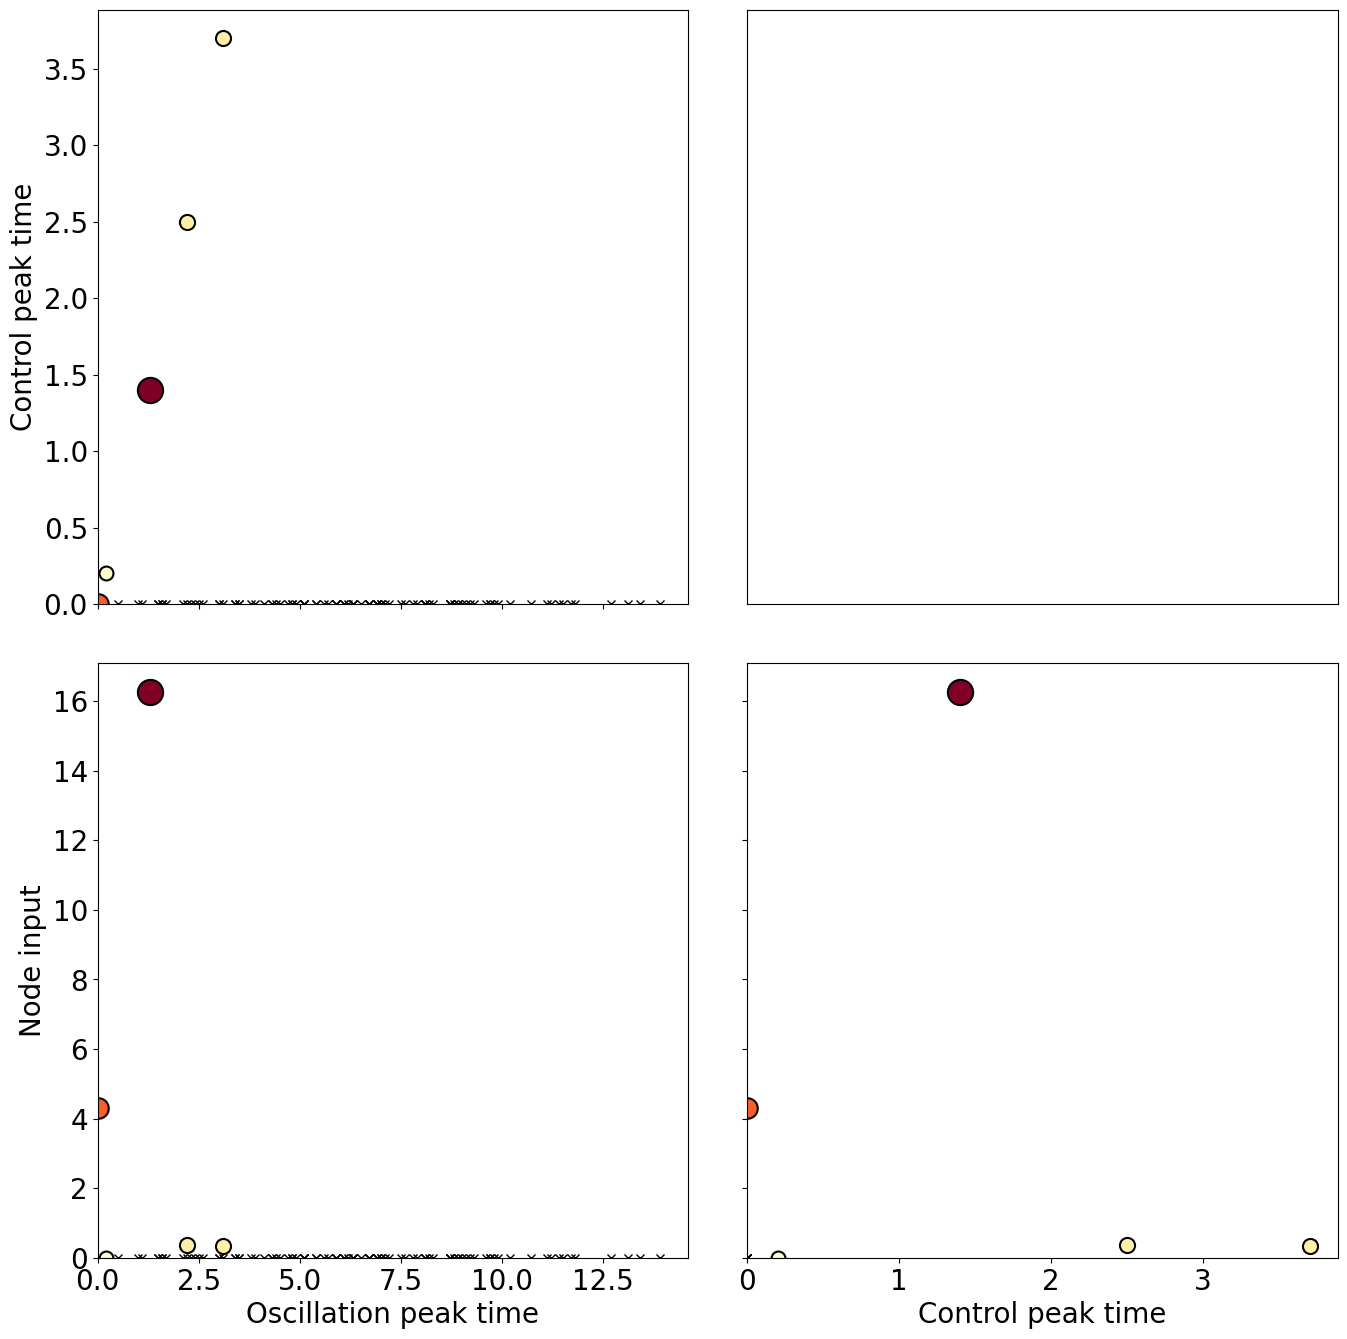

In [142]:
xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate", "theta coordinate", "phi coordinate"]
ylabel = ["Oscillation peak time", "Control peak time", "Node input"]

wi = 0

if True:

    x_array = [av_c[mdn[wi]], wnd[mdn[wi]], nfl[mdn[wi]], coord_data[mdn[wi],0], coord_data[mdn[wi],1], coord_data[mdn[wi],2], r[mdn[wi]], theta[mdn[wi]], phi[mdn[wi]]]
    y_array = [control_times0[wi,mdn[wi]], input_nodewise[wi,mdn[wi]]]

    r_mat_sc_cd_0 = np.zeros((len(x_array), len(y_array)))
    p_mat_sc_cd_0 = np.zeros((len(x_array), len(y_array)))
    
    for ix, x in enumerate(x_array):
        for iy, y in enumerate(y_array):
            result = scipy.stats.pearsonr(x, y, method=method)
            r_val = result.statistic
            p_val = result.pvalue
            r_mat_sc_cd_0[ix, iy] = r_val
            p_mat_sc_cd_0[ix, iy] = p_val

x_array = [av_c, wnd, nfl, coord_data[:,0], coord_data[:,1], coord_data[:,2], r, theta, phi]
y_array = [peak_times0, control_times0[wi,:], input_nodewise[wi,:]]

maxenin = np.amax(input_nodewise[wi,:])
colmap = mpl.cm.get_cmap('YlOrRd')

if True:

    fig, ax = plt.subplots(len(y_array), 1,  figsize=(24, 2*len(y_array)))

    for iy, y in enumerate(y_array):

        a = ax[iy]

        x_axis = np.linspace(np.amin(y), np.amax(y), 100)

        for n in range(N):
            if n in mdn[wi]:
                factor = np.log(1.+input_nodewise[wi,n])/np.log(maxenin)
                a.plot(y[n], 0, marker="o", linestyle="none", markersize=10+(8*factor), markeredgewidth=1.5, markeredgecolor="k", color = colmap(factor), zorder=-1)
            else:
                a.plot(y[n], 0, marker="x", color="k", linestyle="none")
        
        a.hlines(y=0., xmin=x_axis[0], xmax=x_axis[-1], linewidth=1, color='k', zorder=-2)
        a.set_xticks([0.])
        a.set_xticklabels([])
        a.set_yticks([])

        a.spines['right'].set_visible(False)
        a.spines['left'].set_visible(False)
        a.spines['top'].set_visible(False)
        a.spines['bottom'].set_visible(False)

        a.set_ylabel(ylabel[iy], rotation=0)
        a.margins(x=0.2, y=0)
            
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
    plt.savefig(os.path.join(datadir, "linear_sc_0_L1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

if True:

    fig, ax = plt.subplots(len(x_array), 1,  figsize=(24, 2*len(x_array)))

    for iy, y in enumerate(x_array):

        a = ax[iy]

        x_axis = np.linspace(np.amin(y), np.amax(y), 100)

        for n in range(N):
            if n in mdn[wi]:
                factor = np.log(1.+input_nodewise[wi,n])/np.log(maxenin)
                a.plot(y[n], 0, marker="o", linestyle="none", markersize=10+(8*factor), markeredgewidth=1.5, markeredgecolor="k", color = colmap(factor), zorder=-1)
            else:
                a.plot(y[n], 0, marker="x", color="k", linestyle="none")
        
        a.hlines(y=0., xmin=x_axis[0], xmax=x_axis[-1], linewidth=1, color='k', zorder=-2)
        a.set_xticks([0.])
        a.set_xticklabels([])
        a.set_yticks([])

        a.spines['right'].set_visible(False)
        a.spines['left'].set_visible(False)
        a.spines['top'].set_visible(False)
        a.spines['bottom'].set_visible(False)

        a.set_ylabel(xlabel[iy], rotation=0)
        a.margins(x=0.2, y=0)
            
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.1)
    plt.savefig(os.path.join(datadir, "linear_cd_0_L1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()


if True:
    xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate", "theta coordinate", "phi coordinate"]
    ylabel = ["Control peak time", "Node input"]

    annotations = r_mat_sc_cd_0.copy()

    for ix, x in enumerate(xlabel):
        for iy, y in enumerate(ylabel):
            if p_mat_sc_cd_0[ix, iy] >= 0.05:
                annotations[ix, iy] = None

    for ix, x in enumerate(xlabel):
        for iy, y in enumerate(ylabel):
            if np.abs(r_mat_sc_cd_0[ix, iy]) < 0.0:
                annotations[ix, iy] = None

    plt.figure(figsize=(20,20))
    ax = sns.heatmap(annotations, annot=True, fmt='.4f', cmap=cmap, yticklabels=xlabel, xticklabels=ylabel, vmin=-1, vmax=1)
    ax.set_aspect('equal', adjustable='box')
    plt.xticks(rotation=90) 
    plt.savefig(os.path.join(datadir, str(wi) + "_sc_cd_0_L1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

if True:
    xlabel = ["Oscillation peak time", "Control peak time", "Node input"]

    x_array = [peak_times0, control_times0[wi,:], input_nodewise[wi,:]]
    fig, ax = plt.subplots(len(x_array)-1,len(x_array)-1, figsize=( (len(x_array)-1)*8, (len(x_array)-1)*8 ))

    for ix, x in enumerate(x_array):
        for iy, y in enumerate(x_array):

            if ix == 2: continue

            a = ax[iy-1,ix]

            if ix >= iy:
                continue

            for n in range(N):
                if n in mdn[wi]:
                    factor = np.log(1.+input_nodewise[wi,n])/np.log(maxenin)
                    a.plot(x[n], y[n], marker="o", linestyle="none", markersize=10+(8*factor), markeredgewidth=1.5, markeredgecolor="k", color = colmap(factor), zorder=-1)
                else:
                    a.plot(x[n], y[n], marker="x", color="k", linestyle="none")

            x_axis = np.linspace(np.amin(x)*0.95, np.amax(x)*1.05, 100)
            y_axis = np.linspace(np.amin(y)*0.95, np.amax(y)*1.05, 100)
            
            a.set_xlim(x_axis[0], x_axis[-1])
            a.set_ylim(y_axis[0], y_axis[-1])

            if iy == 2:
                a.set_xlabel(xlabel[ix])
            else:
                a.set_xticklabels([])

            if ix == 0:
                a.set_ylabel(xlabel[iy])
            else:
                a.set_yticklabels([])

    ax[0,1].set_xticks([])
    ax[0,1].set_yticks([])

    plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.1, hspace=0.1)
    plt.savefig(os.path.join(datadir, "sc_sc_measures_0_L1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

############ control task 1

[[11, 40, 58, 75, 87, 88, 93], [1, 7, 9, 21, 30, 31, 33, 34, 35, 40, 42, 58, 75, 79, 93], [1, 11, 21, 25, 30, 31, 35, 40, 42, 51, 58, 75, 79, 91, 93, 94]]
7 15 16


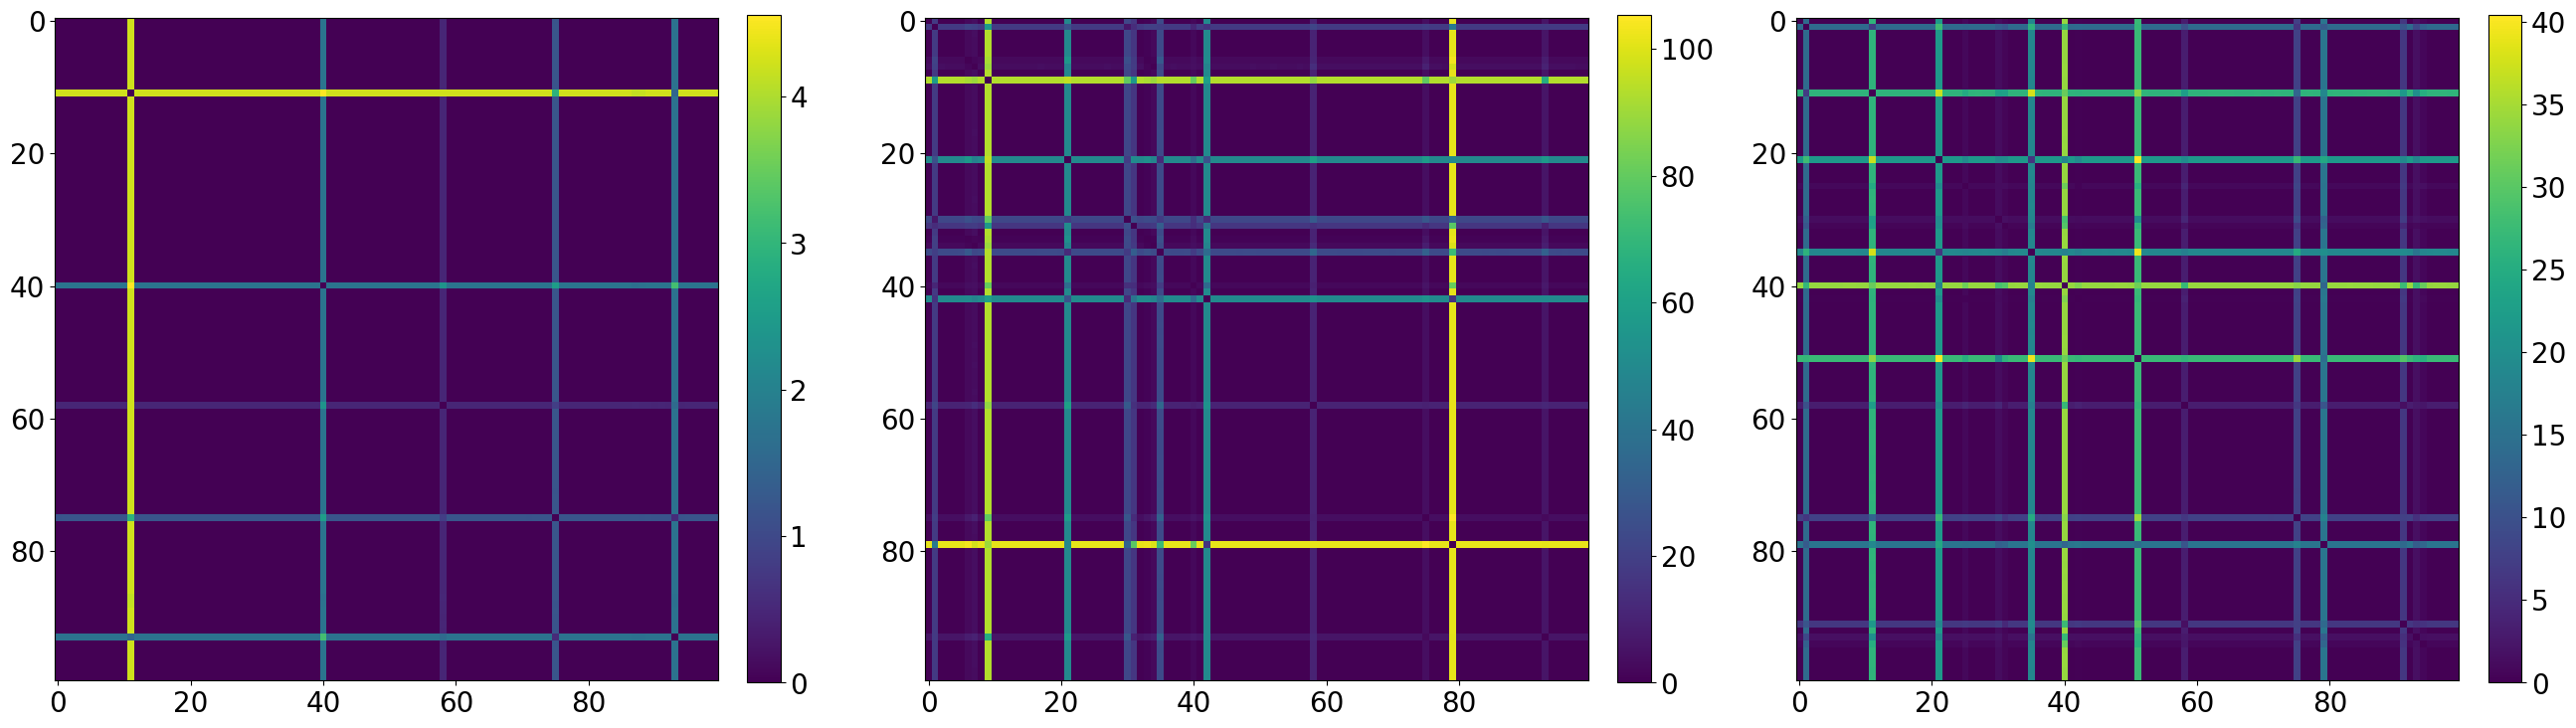

In [20]:
peak_times1 = np.zeros((N))

for n in range(N):
    peak_times1[n] = scipy.signal.find_peaks(data_1["state_uncontrolled"][n,0,:1240], height=0.7)[0][-2]

peak_times1 -= np.amin(peak_times1)
peak_times1 *= dt

energy_nodewise = np.zeros((3,N))
input_nodewise = np.zeros((3,N))
mdn = [[], [], []]

for wi in range(3):
    for n in range(N):
        energy_nodewise[wi,n] = np.sum(data_1["control"][wi][n,0,:])**2 * dt
        input_nodewise[wi,n] = np.sum(np.abs(data_1["control"][wi][n,0,:])) * dt
        if energy_nodewise[wi,n] > 0.4:
            mdn[wi].append(n)

control_times1 = np.zeros((3,N))
min_c = 1000.
for wi in range(3):
    for n in mdn[wi]:
        if len(scipy.signal.find_peaks(np.abs(data_1["control"][wi][n,0,:]))[0]) > 3:
            control_times1[wi,n] = scipy.signal.find_peaks(np.abs(data_1["control"][wi][n,0,:]))[0][-2]
            if control_times1[wi,n] < min_c:
                min_c = control_times1[wi,n]
    control_times1[wi,mdn[wi]] -= min_c

    for n in mdn[wi]:
        control_times1[wi,n] = max(0., control_times1[wi,n])
        
control_times1 *= dt

distmat = np.zeros((3,N,N))
cnd = np.zeros((3,N))

for wi in range(3):
    for n1 in range(N):
        for n2 in range(n1+1, N):
            distmat[wi,n1,n2] = np.sum( (data_1["control"][wi][n1,0,:] - data_1["control"][wi][n2,0,:])**2 )*dt
            distmat[wi,n2,n1] = distmat[wi,n1,n2].copy()

    cnd[wi,:] = np.sum(distmat[wi,:,:], axis=0)
    
print(mdn)
print(len(mdn[0]), len(mdn[1]), len(mdn[2]))

fig, ax = plt.subplots(1,3, figsize=(32,12))
for wi in range(3):
    heatmap = ax[wi].imshow(distmat[wi,:,:])
    bar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)
plt.show()

/tmp/ipykernel_2686281/148854001.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colmap = mpl.cm.get_cmap('YlOrRd')


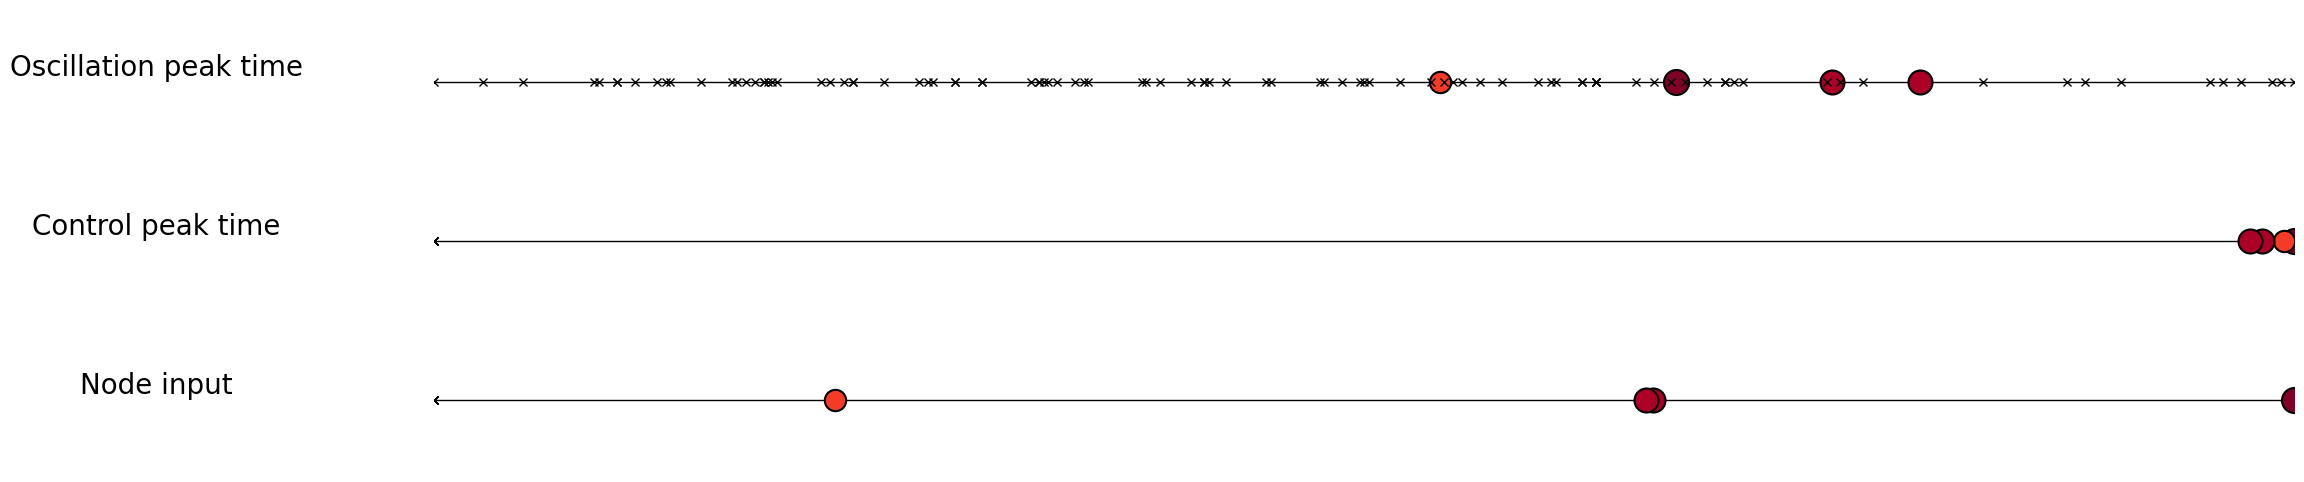

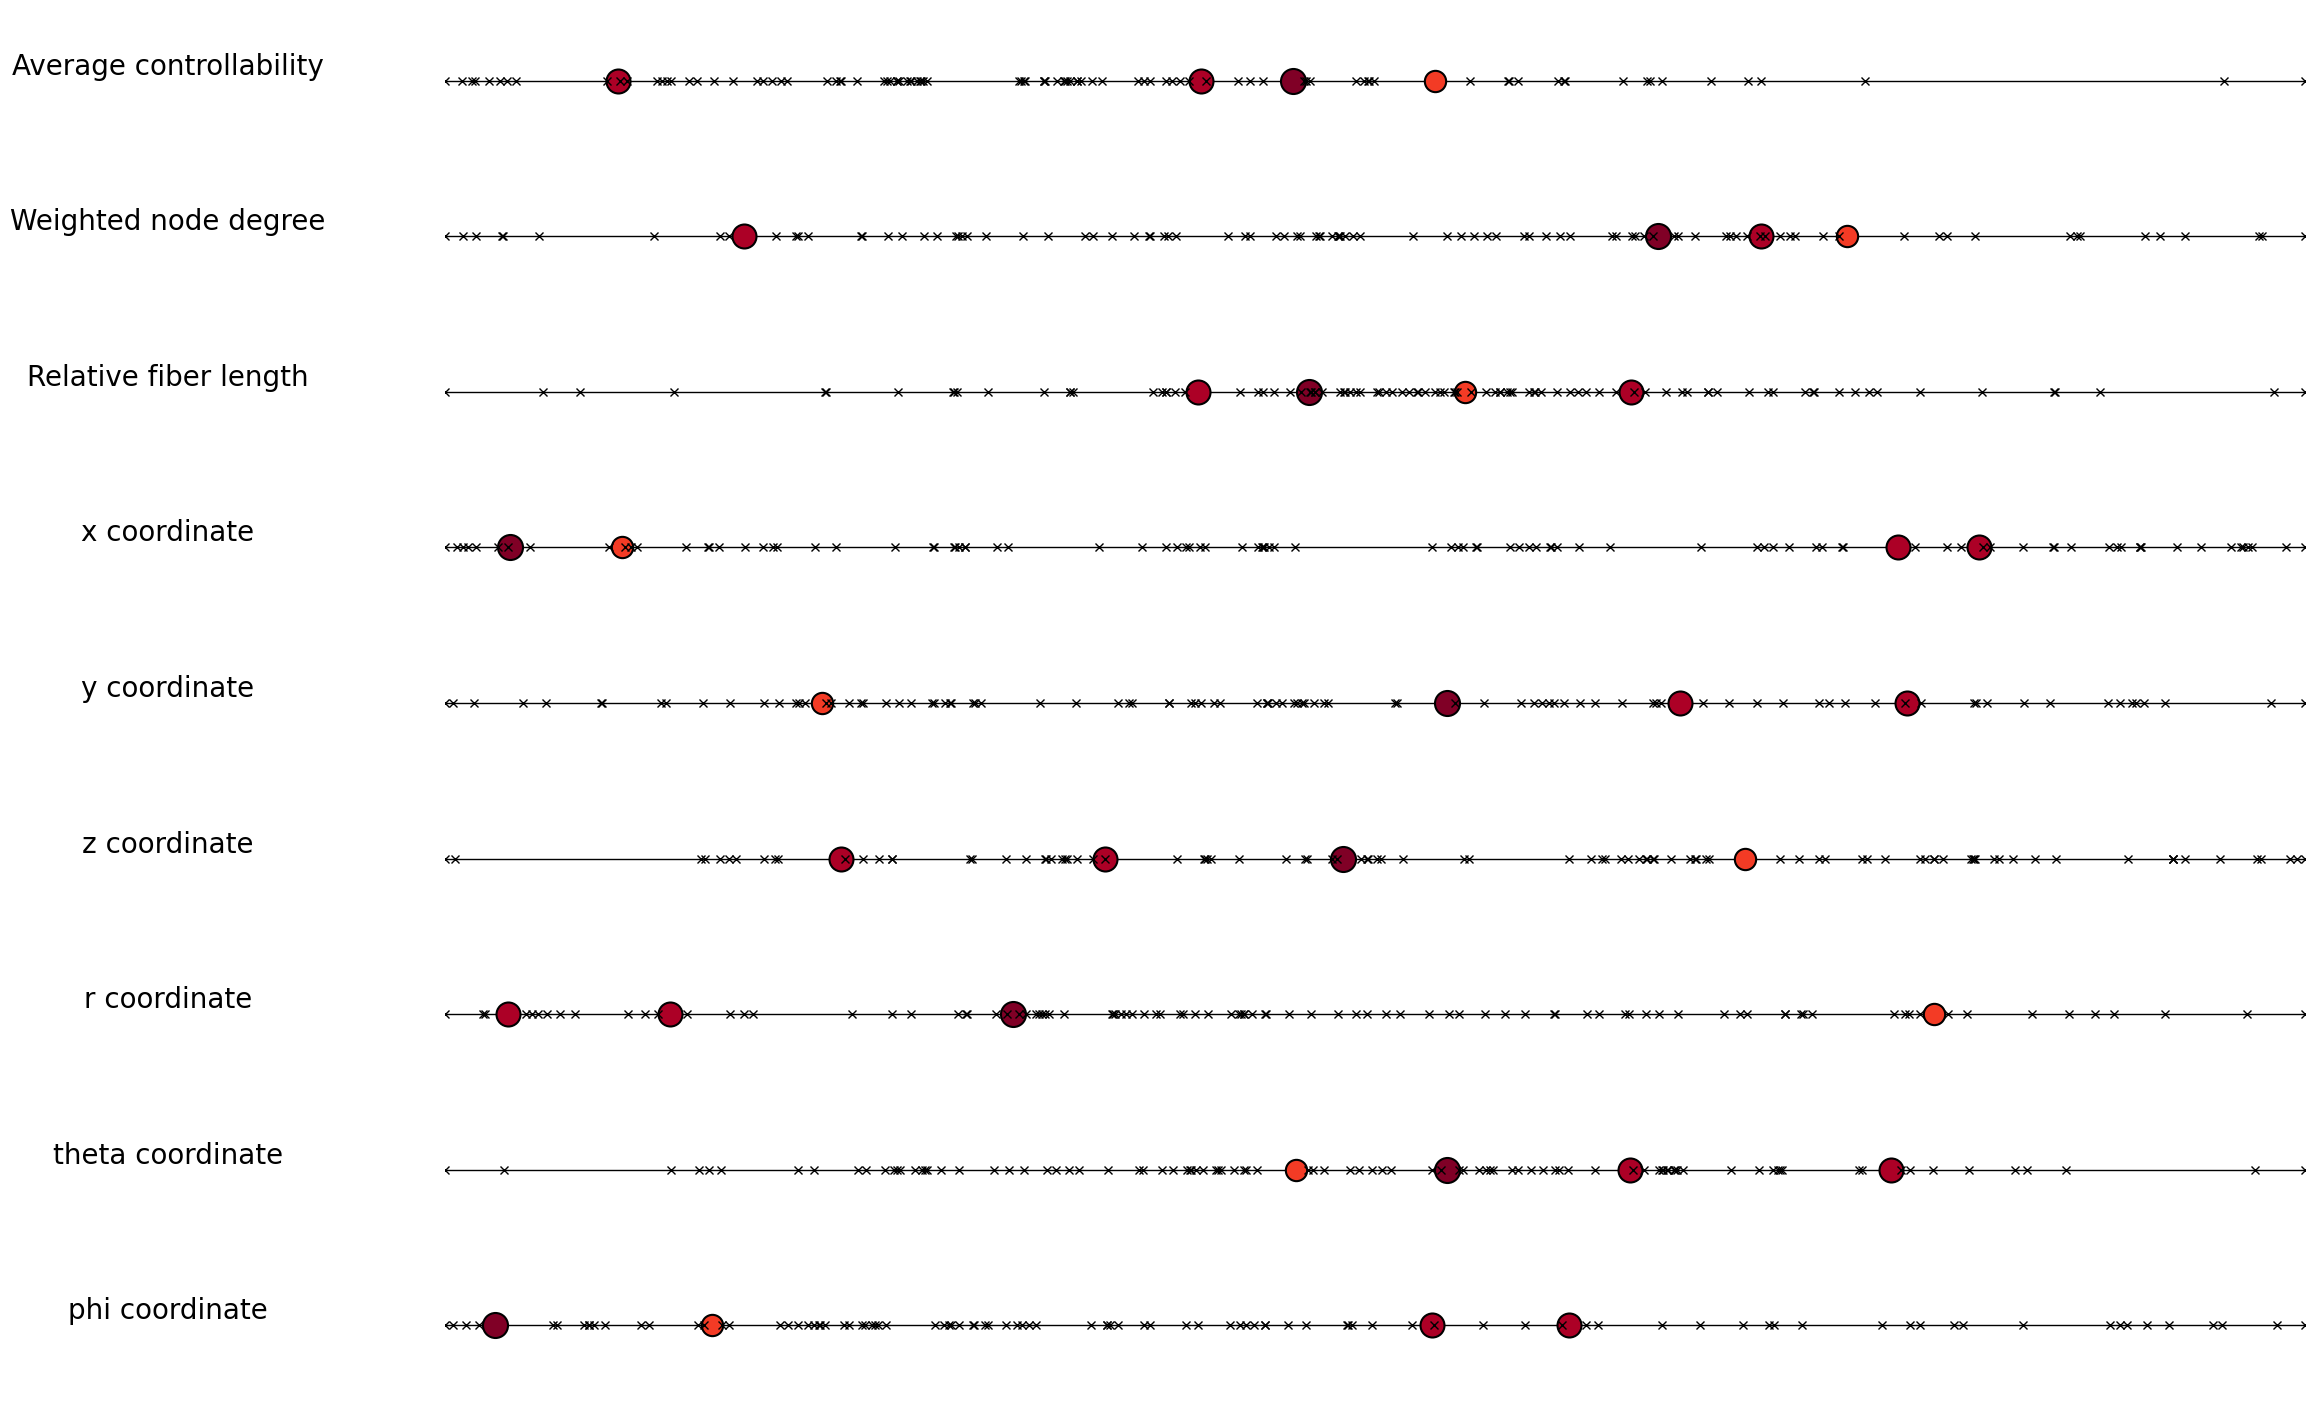

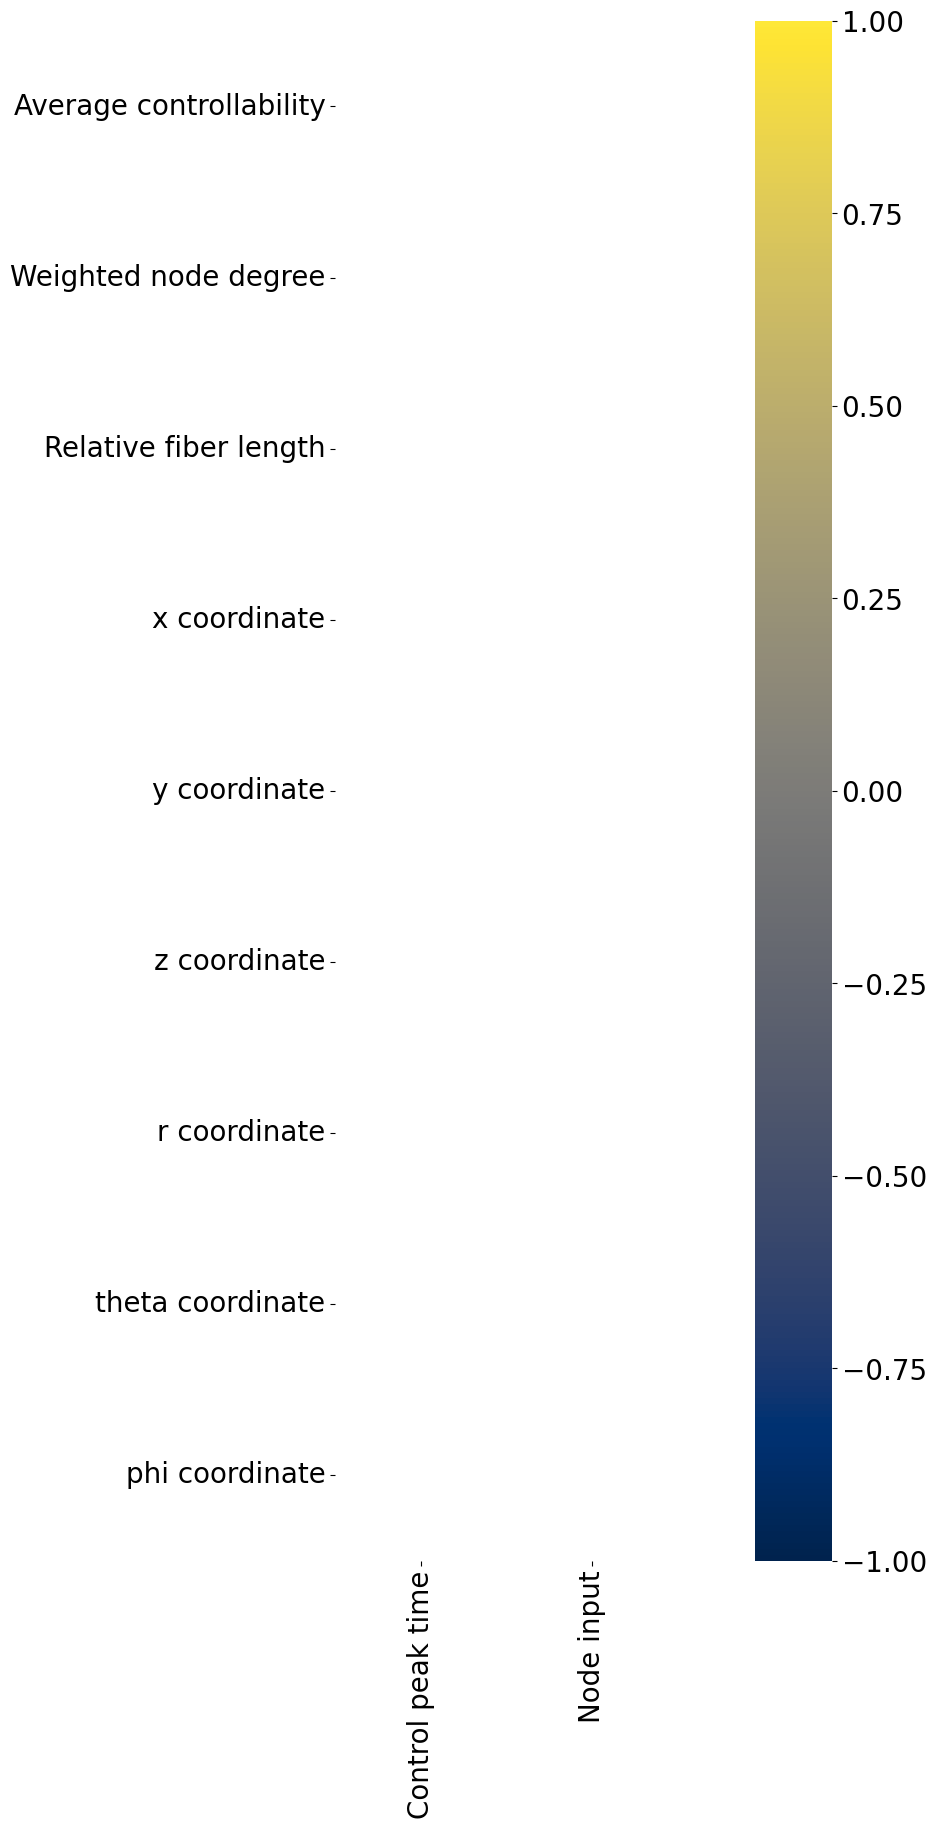

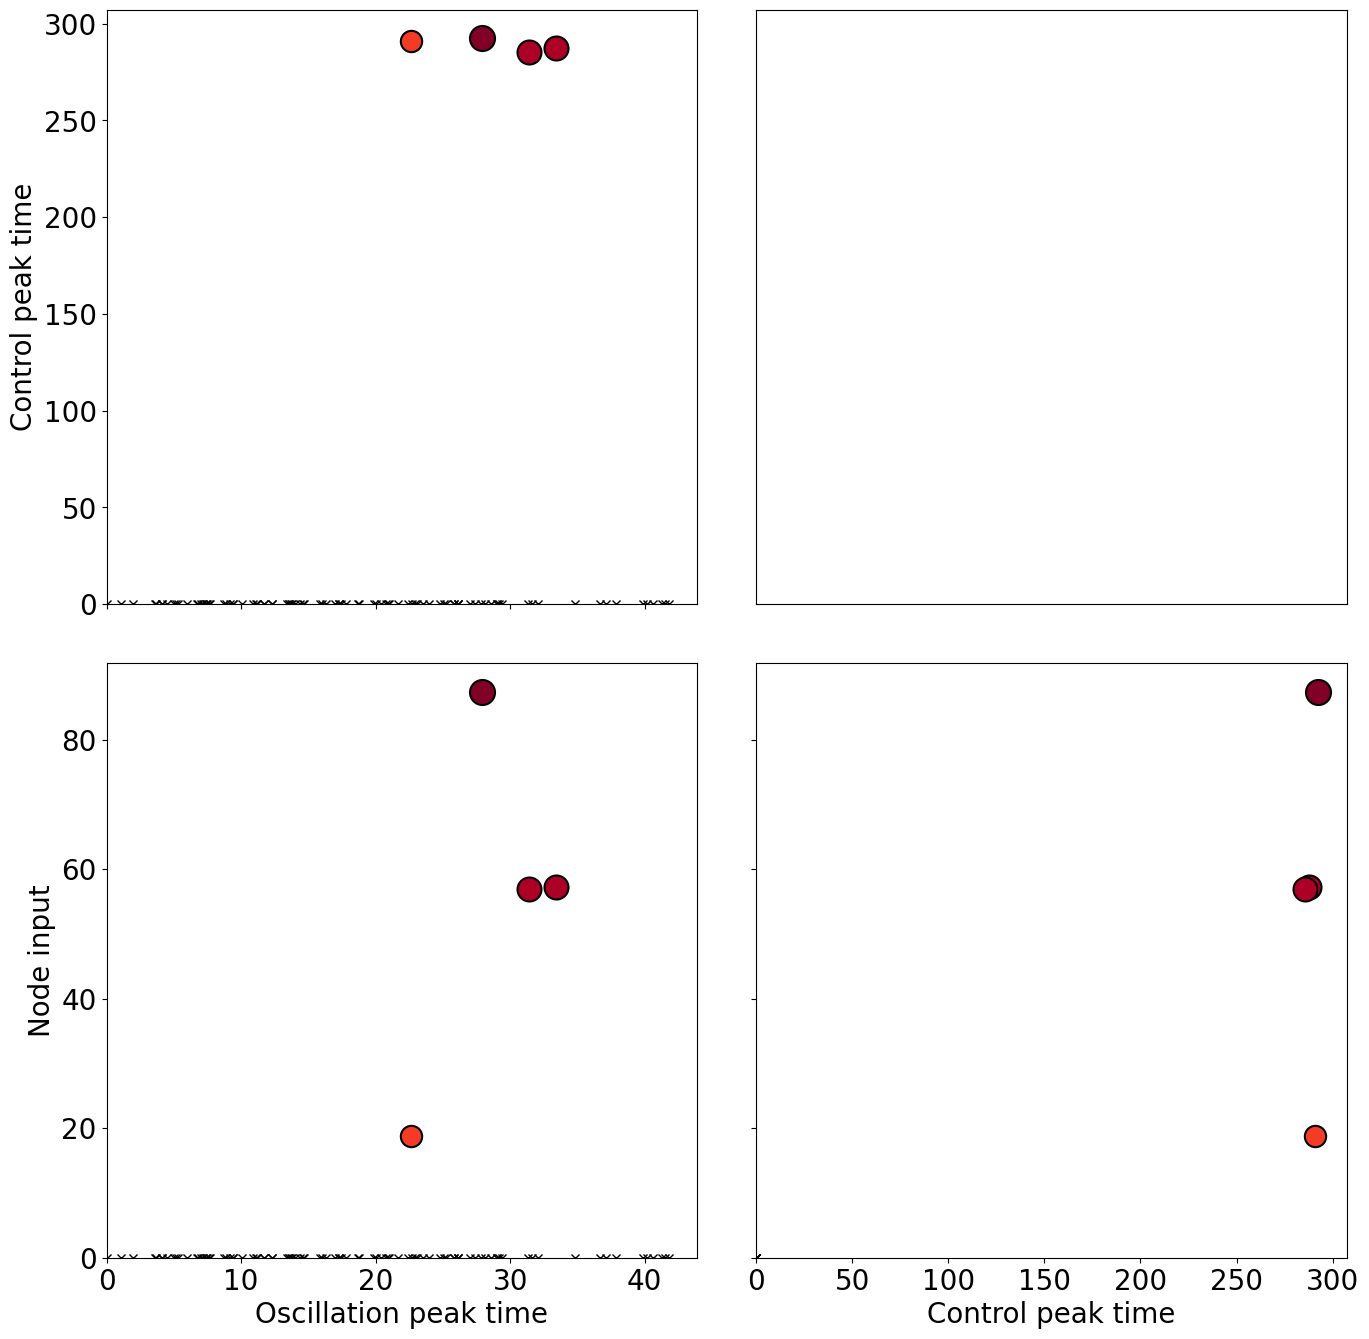

In [182]:
xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate", "theta coordinate", "phi coordinate"]
ylabel = ["Oscillation peak time", "Control peak time", "Node input"]

wi = 0

if True:

    x_array = [av_c[mdn[wi]], wnd[mdn[wi]], nfl[mdn[wi]], coord_data[mdn[wi],0], coord_data[mdn[wi],1], coord_data[mdn[wi],2], r[mdn[wi]], theta[mdn[wi]], phi[mdn[wi]]]
    y_array = [control_times1[wi,mdn[wi]], input_nodewise[wi,mdn[wi]]]

    r_mat_sc_cd_1 = np.zeros((len(x_array), len(y_array)))
    p_mat_sc_cd_1 = np.zeros((len(x_array), len(y_array)))
    for ix, x in enumerate(x_array):
        for iy, y in enumerate(y_array):
            result = scipy.stats.pearsonr(x, y, method=method)
            r_val = result.statistic
            p_val = result.pvalue
            r_mat_sc_cd_1[ix, iy] = r_val
            p_mat_sc_cd_1[ix, iy] = p_val

x_array = [av_c, wnd, nfl, coord_data[:,0], coord_data[:,1], coord_data[:,2], r, theta, phi]
y_array = [peak_times1, control_times1[wi,:], input_nodewise[wi,:]]

maxenin = np.amax(input_nodewise[wi,:])
colmap = mpl.cm.get_cmap('YlOrRd')

if True:

    fig, ax = plt.subplots(len(y_array), 1,  figsize=(24, 2*len(y_array)))

    for iy, y in enumerate(y_array):

        a = ax[iy]

        x_axis = np.linspace(np.amin(y), np.amax(y), 100)

        for n in range(N):
            if n in mdn[wi]:
                factor = np.log(1.+input_nodewise[wi,n])/np.log(maxenin)
                a.plot(y[n], 0, marker="o", linestyle="none", markersize=10+(8*factor), markeredgewidth=1.5, markeredgecolor="k", color = colmap(factor), zorder=-1)
            else:
                a.plot(y[n], 0, marker="x", color="k", linestyle="none")
        
        a.hlines(y=0., xmin=x_axis[0], xmax=x_axis[-1], linewidth=1, color='k', zorder=-2)
        a.set_xticks([])
        a.set_yticks([])
        a.set_xlim(x_axis[0], x_axis[-1])

        a.spines['right'].set_visible(False)
        a.spines['left'].set_visible(False)
        a.spines['top'].set_visible(False)
        a.spines['bottom'].set_visible(False)

        a.set_ylabel(ylabel[iy], rotation=0, labelpad=200)
        a.margins(x=0.3, y=0)
            
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    plt.savefig(os.path.join(datadir, "linear_sc_1_L1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

if True:

    fig, ax = plt.subplots(len(x_array), 1,  figsize=(24, 2*len(x_array)))

    for iy, y in enumerate(x_array):

        a = ax[iy]

        x_axis = np.linspace(np.amin(y), np.amax(y), 100)

        for n in range(N):
            if n in mdn[wi]:
                factor = np.log(1.+input_nodewise[wi,n])/np.log(maxenin)
                a.plot(y[n], 0, marker="o", linestyle="none", markersize=10+(8*factor), markeredgewidth=1.5, markeredgecolor="k", color = colmap(factor), zorder=-1)
            else:
                a.plot(y[n], 0, marker="x", color="k", linestyle="none")
        
        a.hlines(y=0., xmin=x_axis[0], xmax=x_axis[-1], linewidth=1, color='k', zorder=-2)
        a.set_xticks([])
        a.set_yticks([])
        a.set_xlim(x_axis[0], x_axis[-1])

        a.spines['right'].set_visible(False)
        a.spines['left'].set_visible(False)
        a.spines['top'].set_visible(False)
        a.spines['bottom'].set_visible(False)

        a.set_ylabel(xlabel[iy], rotation=0, labelpad=200)
        a.margins(x=0.2, y=0)
            
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.1)
    plt.savefig(os.path.join(datadir, "linear_cd_1_L1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

if True:
    xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate", "theta coordinate", "phi coordinate"]
    ylabel = ["Control peak time", "Node input"]

    annotations = r_mat_sc_cd_1.copy()

    for ix, x in enumerate(xlabel):
        for iy, y in enumerate(ylabel):
            if p_mat_sc_cd_1[ix, iy] >= 0.05:
                annotations[ix, iy] = None

    for ix, x in enumerate(xlabel):
        for iy, y in enumerate(ylabel):
            if np.abs(r_mat_sc_cd_1[ix, iy]) < 0.0:
                annotations[ix, iy] = None

    plt.figure(figsize=(20,20))
    ax = sns.heatmap(annotations, annot=True, fmt='.4f', cmap=cmap, yticklabels=xlabel, xticklabels=ylabel, vmin=-1, vmax=1)
    ax.set_aspect('equal', adjustable='box')
    plt.xticks(rotation=90) 
    plt.savefig(os.path.join(datadir, str(wi) + "_sc_cd_1_L1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

if True:
    xlabel = ["Oscillation peak time", "Control peak time", "Node input"]

    x_array = [peak_times1, control_times1[wi,:], input_nodewise[wi,:]]
    fig, ax = plt.subplots(len(x_array)-1,len(x_array)-1, figsize=( (len(x_array)-1)*8, (len(x_array)-1)*8 ))

    for ix, x in enumerate(x_array):
        for iy, y in enumerate(x_array):

            if ix == 2: continue

            a = ax[iy-1,ix]

            if ix >= iy:
                continue

            for n in range(N):
                if n in mdn[wi]:
                    factor = np.log(1.+input_nodewise[wi,n])/np.log(maxenin)
                    a.plot(x[n], y[n], marker="o", linestyle="none", markersize=10+(8*factor), markeredgewidth=1.5, markeredgecolor="k", color = colmap(factor), zorder=-1)
                else:
                    a.plot(x[n], y[n], marker="x", color="k", linestyle="none")

            x_axis = np.linspace(np.amin(x)*0.95, np.amax(x)*1.05, 100)
            y_axis = np.linspace(np.amin(y)*0.95, np.amax(y)*1.05, 100)
            
            a.set_xlim(x_axis[0], x_axis[-1])
            a.set_ylim(y_axis[0], y_axis[-1])

            if iy == 2:
                a.set_xlabel(xlabel[ix])
            else:
                a.set_xticklabels([])

            if ix == 0:
                a.set_ylabel(xlabel[iy])
            else:
                a.set_yticklabels([])

    ax[0,1].set_xticks([])
    ax[0,1].set_yticks([])

    plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.1, hspace=0.1)
    plt.savefig(os.path.join(datadir, "sc_sc_measures_1_L1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

################# control task 2

0.0 2.5677946833729295
0.0 2.728294321002789
0.0 9.678650858822277
[[36, 64, 68, 71, 80], [31, 36, 68, 71, 81, 85, 86], [31, 36, 68, 71, 81, 85, 86]]
5 7 7


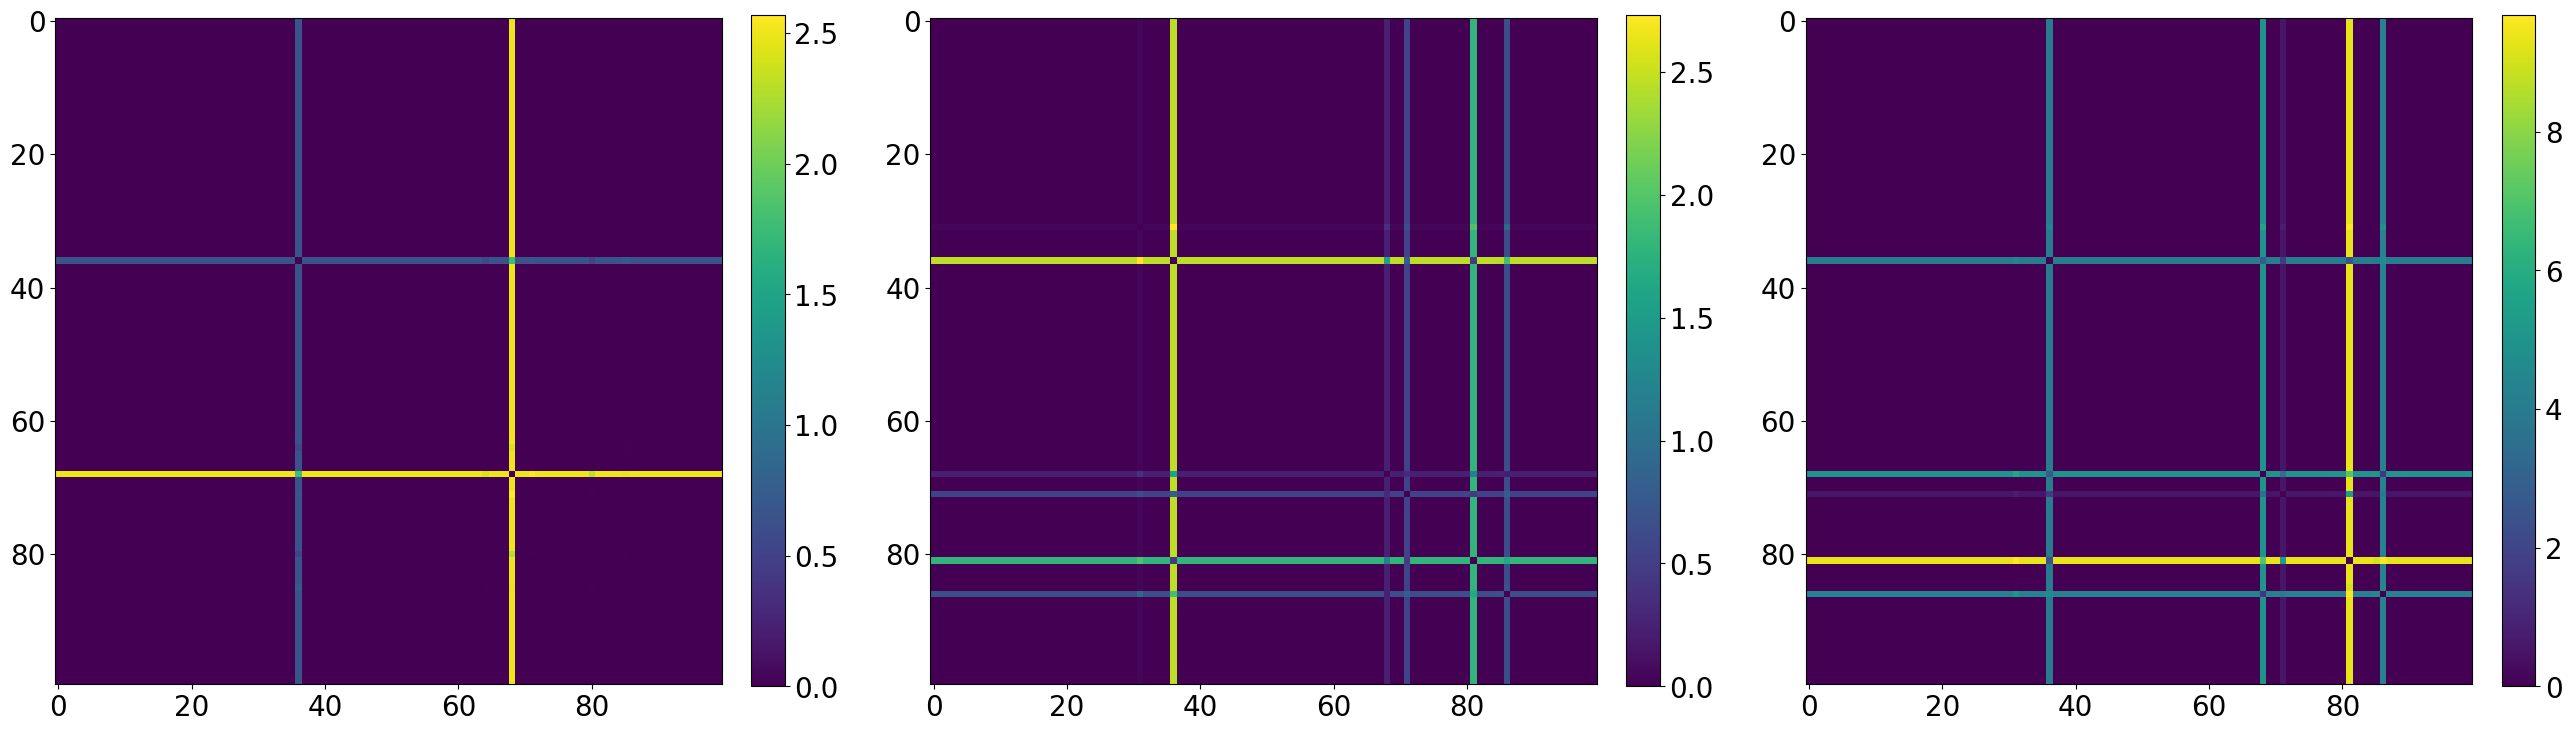

In [21]:
peak_times2 = np.zeros((N))

for n in range(N):
    peak_times2[n] = scipy.signal.find_peaks(data_2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]

peak_times2 -= np.amin(peak_times2)
peak_times2 *= dt

peak_time_order2 = np.argsort(peak_times2)

energy_nodewise = np.zeros((3,N))
input_nodewise = np.zeros((3,N))
mdn = [[], [], []]

for wi in range(3):
    for n in range(N):
        energy_nodewise[wi,n] = np.sum(data_2["control"][wi][n,0,:])**2 * dt
        input_nodewise[wi,n] = np.sum(np.abs(data_2["control"][wi][n,0,:])) * dt
        if energy_nodewise[wi,n] > 1e-1:
            mdn[wi].append(n)

control_times2 = np.zeros((3,N))
min_c = 1000.
for wi in range(3):
    for n in mdn[wi]:
        if len(scipy.signal.find_peaks(np.abs(data_2["control"][wi][n,0,:]))[0]) > 0:
            control_times2[wi,n] = scipy.signal.find_peaks(np.abs(data_2["control"][wi][n,0,:]))[0][0]
            if control_times2[wi,n] < min_c:
                min_c = control_times2[wi,n]
    control_times2[wi,mdn[wi]] -= min_c

    for n in mdn[wi]:
        control_times2[wi,n] = max(0., control_times2[wi,n])
        
control_times2 *= dt

distmat = np.zeros((3,N,N))
cnd = np.zeros((3,N))

for wi in range(3):
    for n1 in range(N):
        for n2 in range(n1+1, N):
            distmat[wi,n1,n2] = np.sum( (data_2["control"][wi][n1,0,:] - data_2["control"][wi][n2,0,:])**2 )*dt
            distmat[wi,n2,n1] = distmat[wi,n1,n2].copy()

    cnd[wi,:] = np.sum(distmat[wi,:,:], axis=0)
        
    print(np.amin(distmat[wi,:,:]), np.amax(distmat[wi,:,:]))
print(mdn)
print(len(mdn[0]), len(mdn[1]), len(mdn[2]))

fig, ax = plt.subplots(1,3, figsize=(32,12))
for wi in range(3):
    heatmap = ax[wi].imshow(distmat[wi,:,:])
    bar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)
plt.show()

/tmp/ipykernel_2686281/2564559486.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colmap = mpl.cm.get_cmap('YlOrRd')


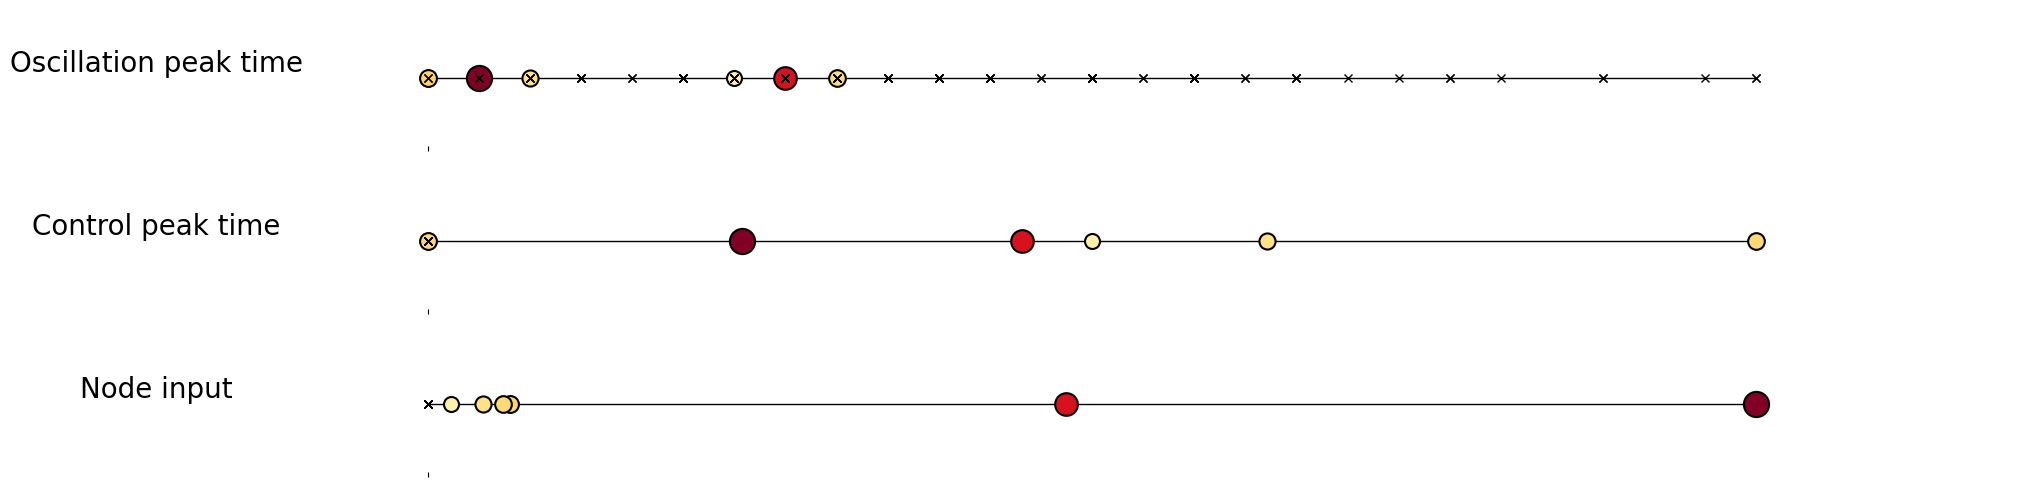

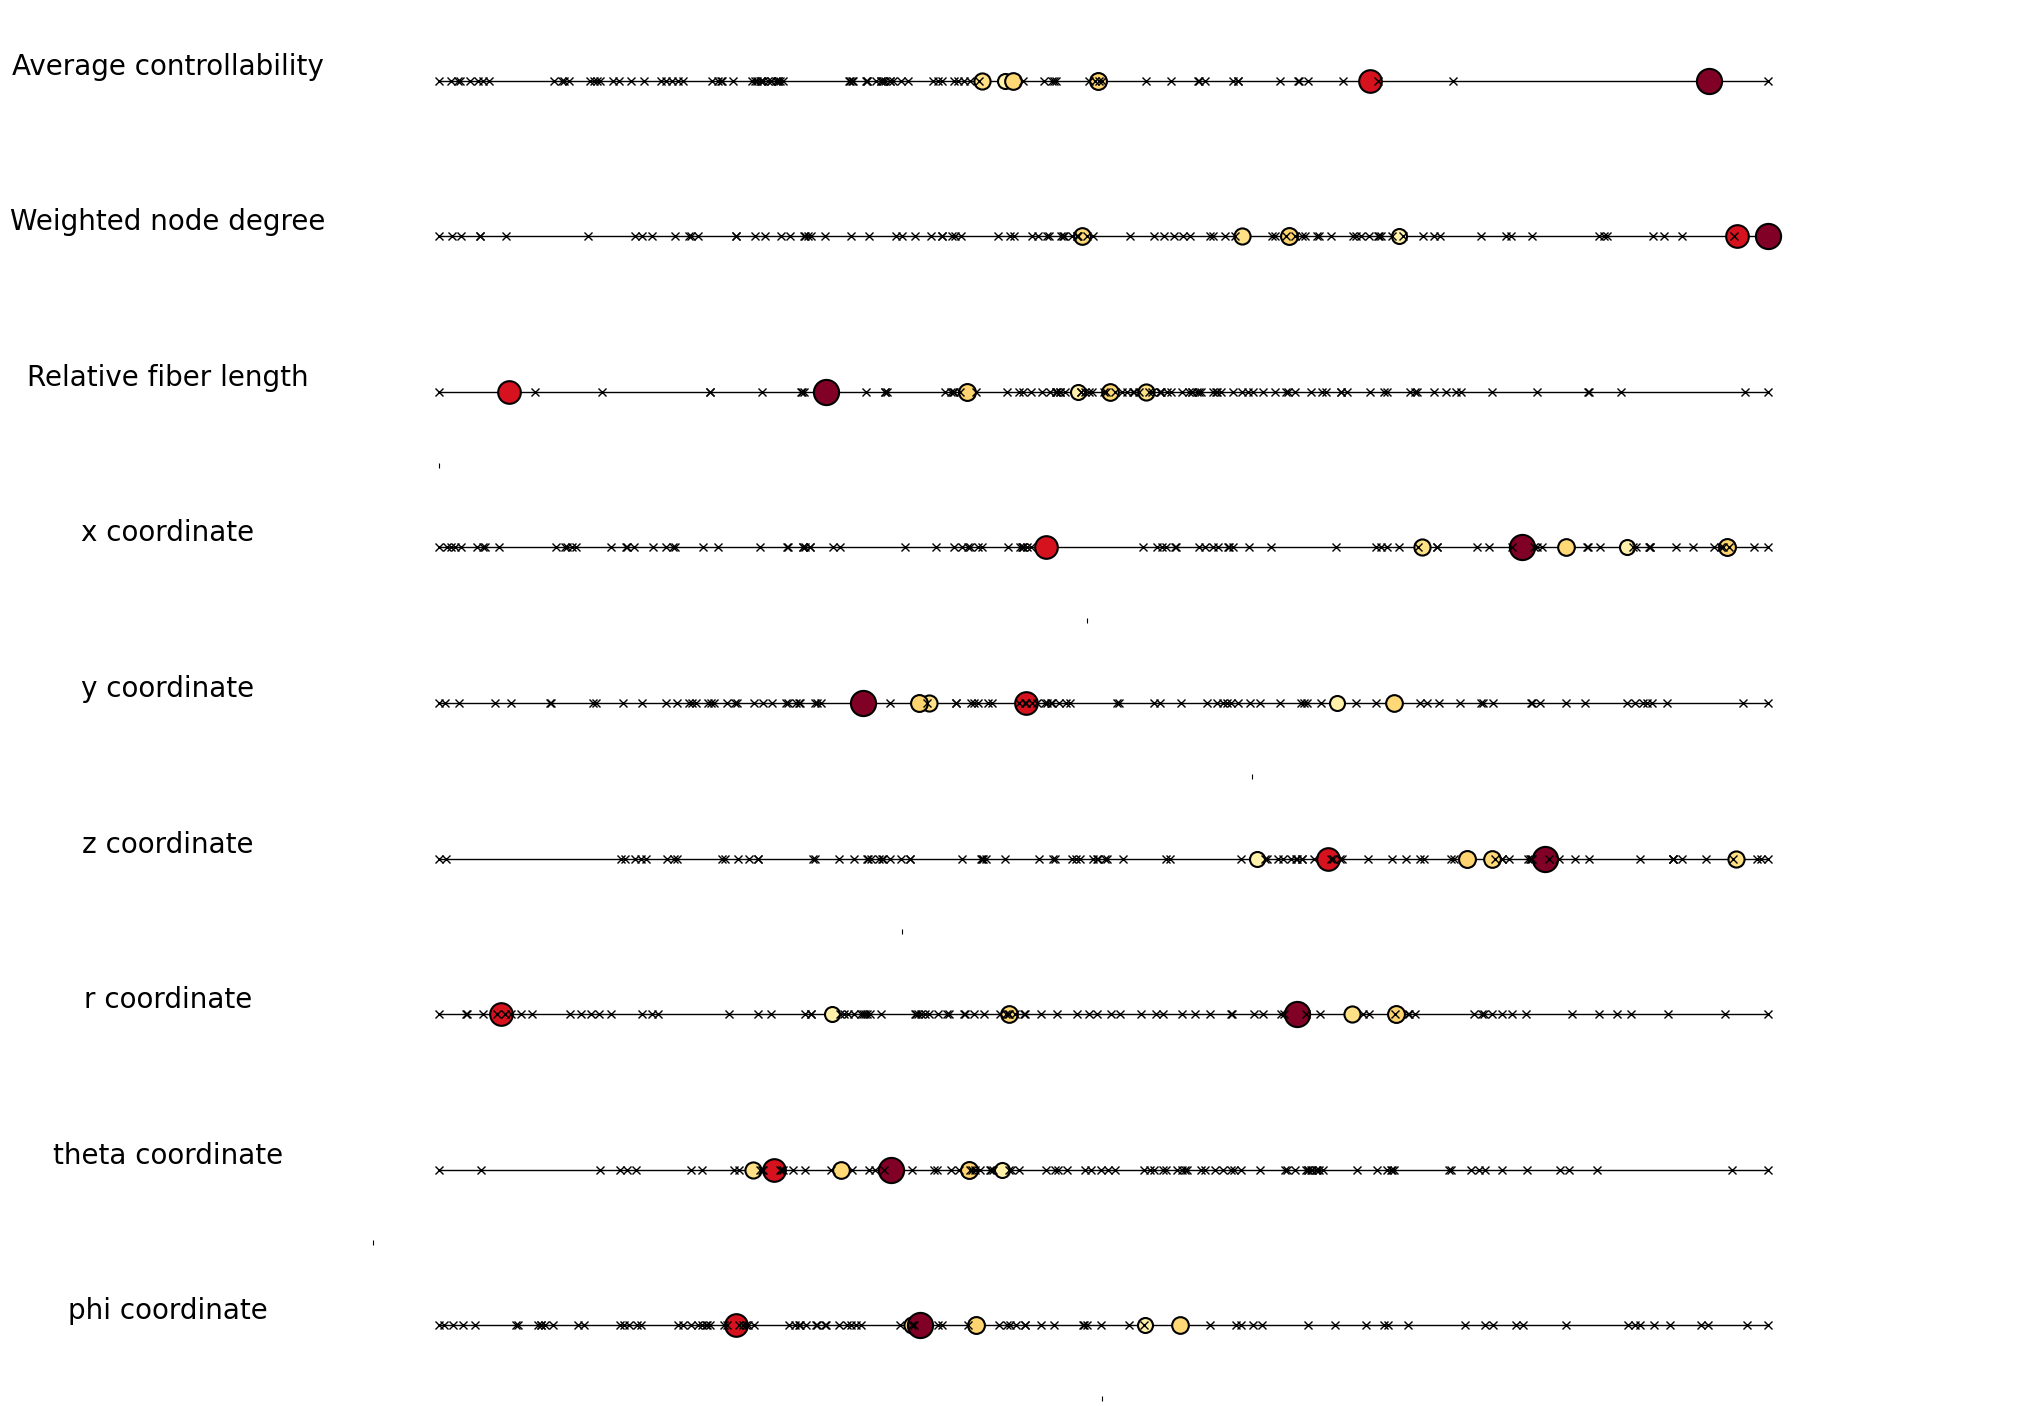

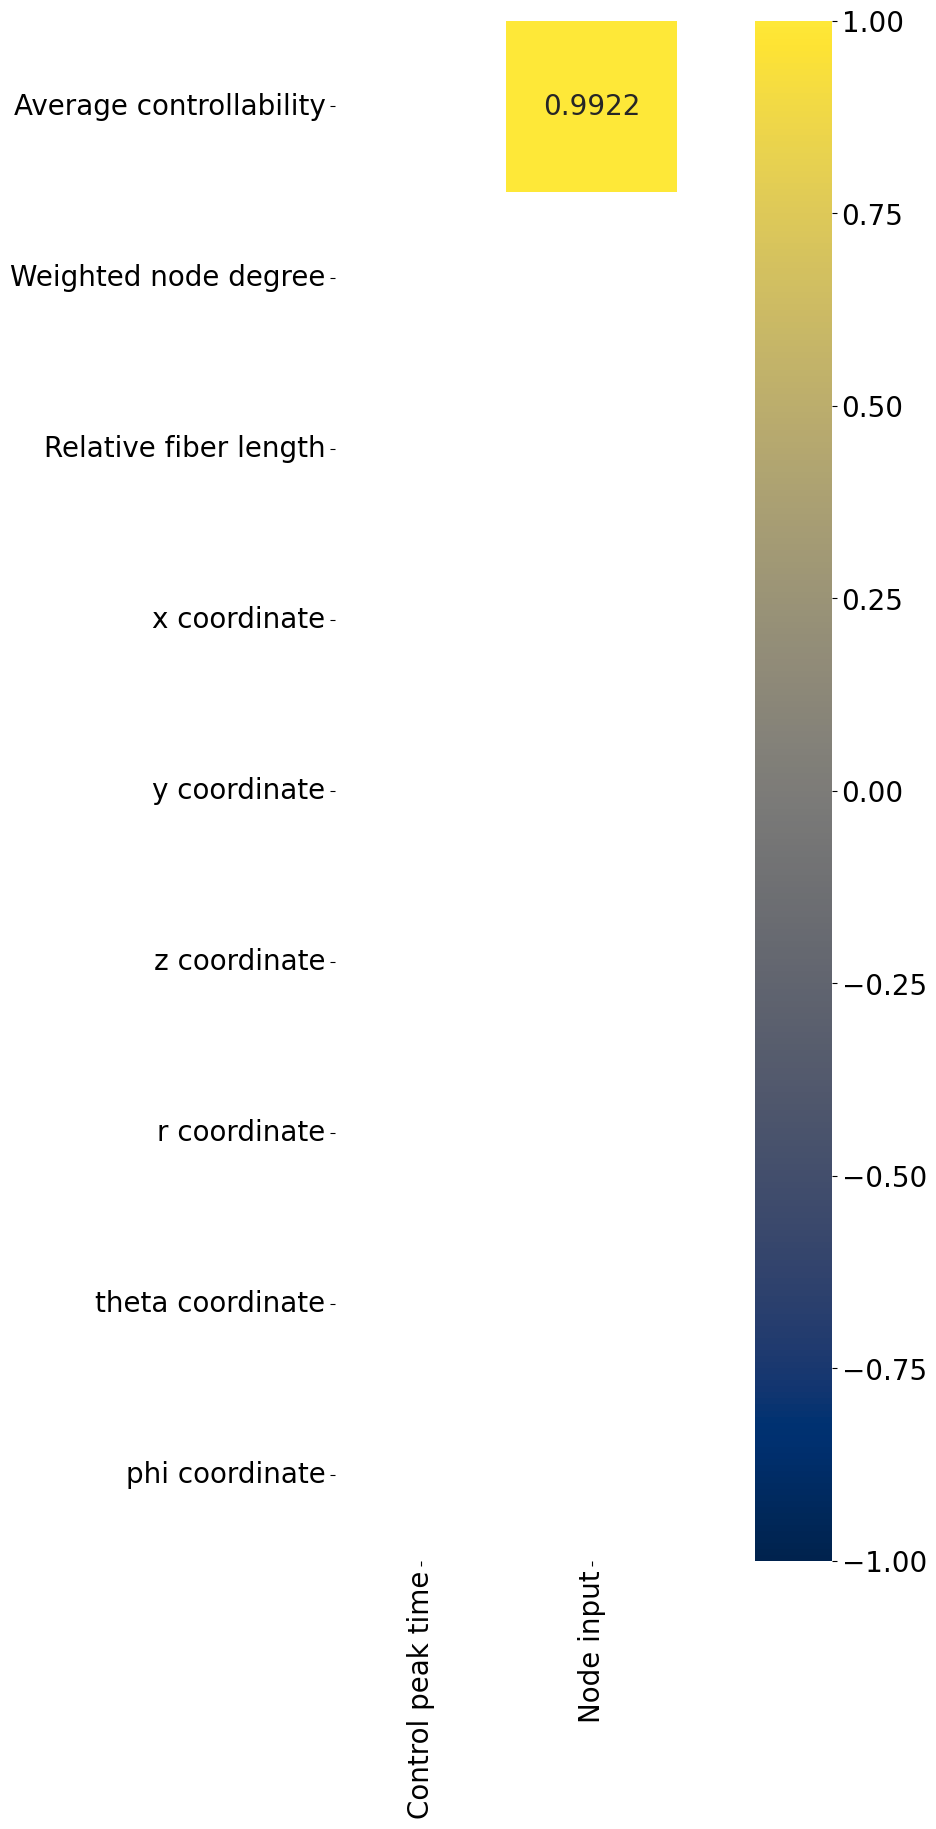

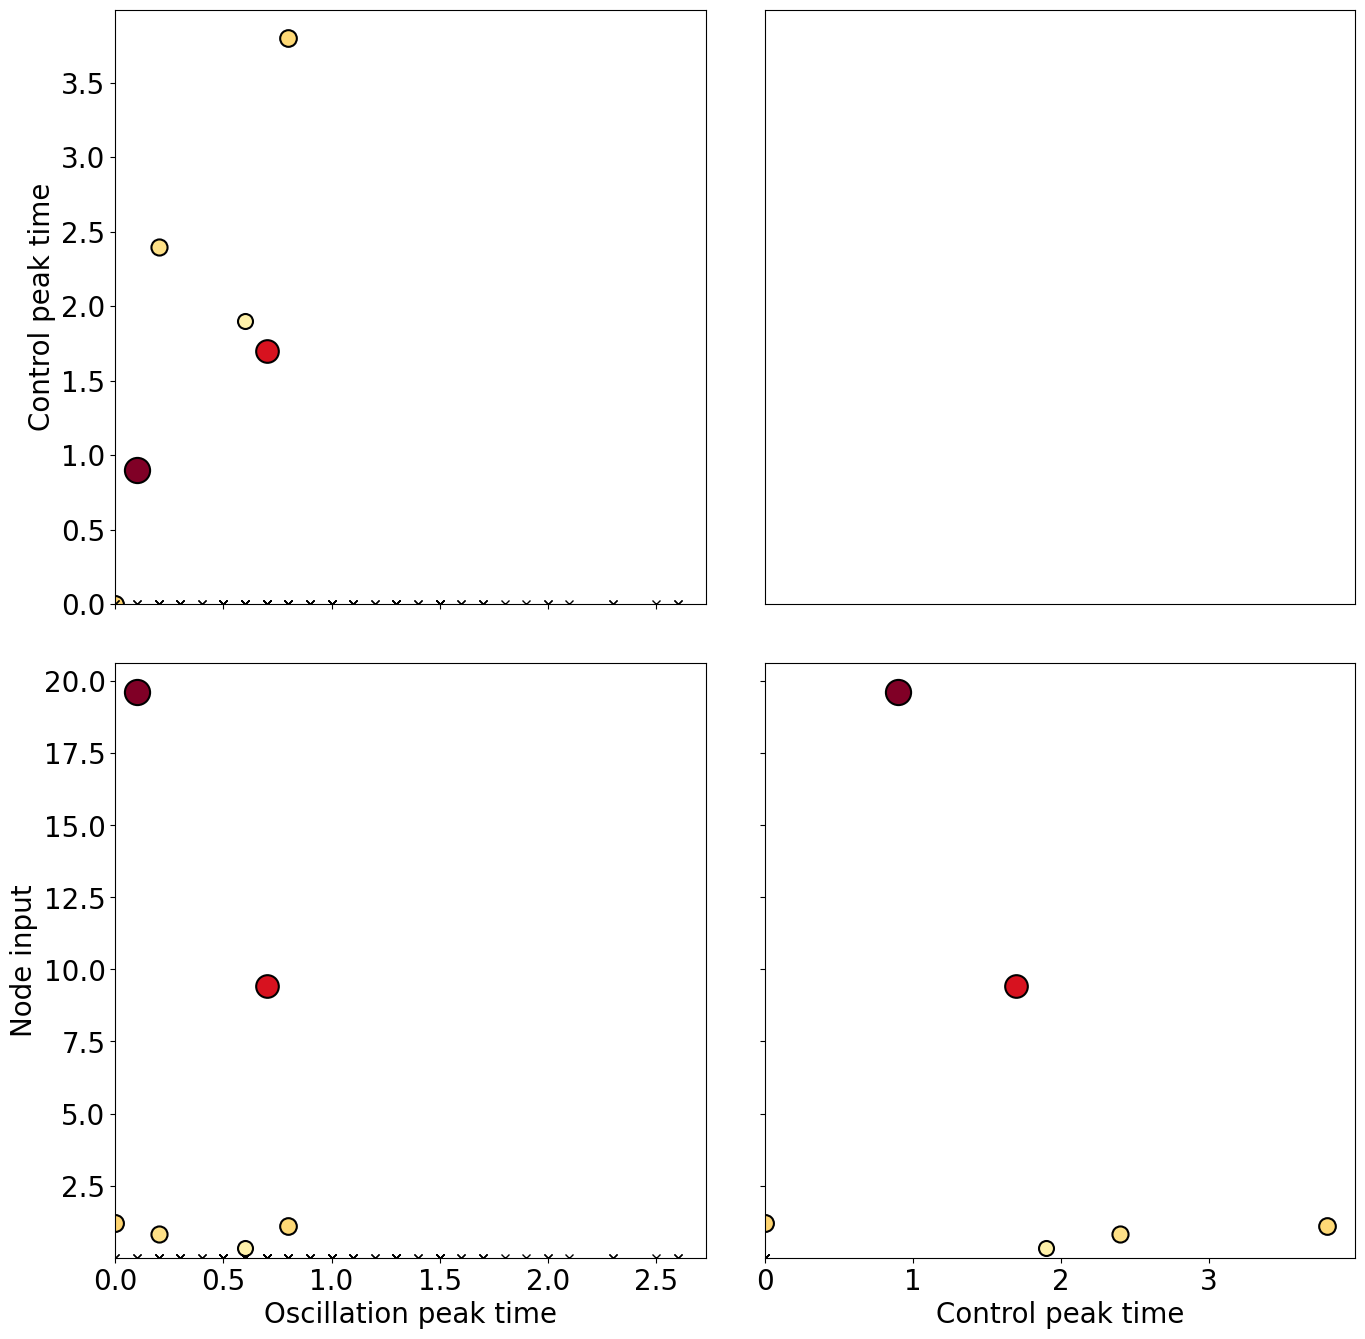

In [190]:
xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate", "theta coordinate", "phi coordinate"]
ylabel = ["Oscillation peak time", "Control peak time", "Node input"]

wi = 0

if True:

    x_array = [av_c[mdn[wi]], wnd[mdn[wi]], nfl[mdn[wi]], coord_data[mdn[wi],0], coord_data[mdn[wi],1], coord_data[mdn[wi],2], r[mdn[wi]], theta[mdn[wi]], phi[mdn[wi]]]
    y_array = [control_times2[wi,mdn[wi]], input_nodewise[wi,mdn[wi]]]

    r_mat_sc_cd_2 = np.zeros((len(x_array), len(y_array)))
    p_mat_sc_cd_2= np.zeros((len(x_array), len(y_array)))
    for ix, x in enumerate(x_array):
        for iy, y in enumerate(y_array):
            result = scipy.stats.pearsonr(x, y, method=method)
            r_val = result.statistic
            p_val = result.pvalue
            r_mat_sc_cd_2[ix, iy] = r_val
            p_mat_sc_cd_2[ix, iy] = p_val

x_array = [av_c, wnd, nfl, coord_data[:,0], coord_data[:,1], coord_data[:,2], r, theta, phi]
y_array = [peak_times2, control_times2[wi,:], input_nodewise[wi,:]]

maxenin = np.amax(input_nodewise[wi,:])
colmap = mpl.cm.get_cmap('YlOrRd')

if True:

    fig, ax = plt.subplots(len(y_array), 1,  figsize=(24, 2*len(y_array)))

    for iy, y in enumerate(y_array):

        a = ax[iy]

        x_axis = np.linspace(np.amin(y), np.amax(y), 100)

        for n in range(N):
            if n in mdn[wi]:
                factor = np.log(1.+input_nodewise[wi,n])/np.log(maxenin)
                a.plot(y[n], 0, marker="o", linestyle="none", markersize=10+(8*factor), markeredgewidth=1.5, markeredgecolor="k", color = colmap(factor), zorder=-1)
            else:
                a.plot(y[n], 0, marker="x", color="k", linestyle="none")
        
        a.hlines(y=0., xmin=x_axis[0], xmax=x_axis[-1], linewidth=1, color='k', zorder=-2)
        a.set_xticks([0])
        a.set_xticklabels([])
        a.set_yticks([])

        a.spines['right'].set_visible(False)
        a.spines['left'].set_visible(False)
        a.spines['top'].set_visible(False)
        a.spines['bottom'].set_visible(False)

        a.set_ylabel(ylabel[iy], rotation=0)
        a.margins(x=0.2, y=0)
            
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
    plt.savefig(os.path.join(datadir, "linear_sc_2_L1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()

if True:

    fig, ax = plt.subplots(len(x_array), 1,  figsize=(24, 2*len(x_array)))

    for iy, y in enumerate(x_array):

        a = ax[iy]

        x_axis = np.linspace(np.amin(y), np.amax(y), 100)

        for n in range(N):
            if n in mdn[wi]:
                factor = np.log(1.+input_nodewise[wi,n])/np.log(maxenin)
                a.plot(y[n], 0, marker="o", linestyle="none", markersize=10+(8*factor), markeredgewidth=1.5, markeredgecolor="k", color = colmap(factor), zorder=-1)
            else:
                a.plot(y[n], 0, marker="x", color="k", linestyle="none")
        
        a.hlines(y=0., xmin=x_axis[0], xmax=x_axis[-1], linewidth=1, color='k', zorder=-2)
        a.set_xticks([0])
        a.set_xticklabels([])
        a.set_yticks([])

        a.spines['right'].set_visible(False)
        a.spines['left'].set_visible(False)
        a.spines['top'].set_visible(False)
        a.spines['bottom'].set_visible(False)

        a.set_ylabel(xlabel[iy], rotation=0)
        a.margins(x=0.2, y=0)
            
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.1)
    plt.savefig(os.path.join(datadir, "linear_cd_2_L1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()


if True:
    xlabel = ["Average controllability", "Weighted node degree", "Relative fiber length", "x coordinate", "y coordinate", "z coordinate", "r coordinate", "theta coordinate", "phi coordinate"]
    ylabel = ["Control peak time", "Node input"]

    annotations = r_mat_sc_cd_2.copy()

    for ix, x in enumerate(xlabel):
        for iy, y in enumerate(ylabel):
            if p_mat_sc_cd_2[ix, iy] >= 0.05:
                annotations[ix, iy] = None

    for ix, x in enumerate(xlabel):
        for iy, y in enumerate(ylabel):
            if np.abs(r_mat_sc_cd_2[ix, iy]) < 0.0:
                annotations[ix, iy] = None

    plt.figure(figsize=(20,20))
    ax = sns.heatmap(annotations, annot=True, fmt='.4f', cmap=cmap, yticklabels=xlabel, xticklabels=ylabel, vmin=-1, vmax=1)
    ax.set_aspect('equal', adjustable='box')
    plt.xticks(rotation=90) 
    plt.savefig(os.path.join(datadir, str(wi) + "_sc_cd_2_L1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()


if True:
    xlabel = ["Oscillation peak time", "Control peak time", "Node input"]

    x_array = [peak_times2, control_times2[wi,:], input_nodewise[wi,:]]
    fig, ax = plt.subplots(len(x_array)-1,len(x_array)-1, figsize=( (len(x_array)-1)*8, (len(x_array)-1)*8 ))

    for ix, x in enumerate(x_array):
        for iy, y in enumerate(x_array):

            if ix == 2: continue

            a = ax[iy-1,ix]

            if ix >= iy:
                continue

            for n in range(N):
                if n in mdn[wi]:
                    factor = np.log(1.+input_nodewise[wi,n])/np.log(maxenin)
                    a.plot(x[n], y[n], marker="o", linestyle="none", markersize=10+(8*factor), markeredgewidth=1.5, markeredgecolor="k", color = colmap(factor), zorder=-1)
                else:
                    a.plot(x[n], y[n], marker="x", color="k", linestyle="none")

            x_axis = np.linspace(np.amin(x)*0.95, np.amax(x)*1.05, 100)
            y_axis = np.linspace(np.amin(y)*0.95, np.amax(y)*1.05, 100)
            
            a.set_xlim(x_axis[0], x_axis[-1])
            a.set_ylim(y_axis[0], y_axis[-1])

            if iy == 2:
                a.set_xlabel(xlabel[ix])
            else:
                a.set_xticklabels([])

            if ix == 0:
                a.set_ylabel(xlabel[iy])
            else:
                a.set_yticklabels([])

    ax[0,1].set_xticks([])
    ax[0,1].set_yticks([])

    plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.1, hspace=0.1)
    plt.savefig(os.path.join(datadir, "sc_sc_measures_2_L1.jpg"), bbox_inches='tight', dpi=300)
    plt.show()